In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import seaborn as sns
from scipy.special import softmax

import utilities as utils

### Script parameters and variables

In [52]:
### operational parameters ###

savedir = "./Figures/"
savefigflag = True
savedataflag = True # save data produced by this notebook
loaddataflag = True # load data already produced by this notebook, instead of re-running analyses

beads_datadir = "./Data/beads/"
horses_datadir = "./Data/horses/"

# number of threads for parallelized analyses
N_threads = 14


### parameters governing analyses ###

# confidence interval of I(R;Y) for bootstrapping analyses
CI = (2.5, 97.5)
boot_iters = 1000 # number of bootstrap iterations

# number of beads to include in X, from current trial backward (bead-prediction experiment) for "fully-optimal" strategy
wsize = 7

# limit for the number of iterations for the IB algorithm
IB_iterlimit = 100000
N_b_ib = 1000 # number of beta points to sample for the standard IB algorithm
max_b_ib = 50 # maximum beta value to sample for the standard IB algorithm
N_b_softmax = 10000 # number of betastar points to sample for the softmax solution
max_b_softmax = 50 # maximum betastar value to sample for the softmax solution


### fixed parameters for the generative structure of the experiments ###

# generative parameters for the bead-prediction experiment
h_=0.99 # jar stay probability
p0_=0.8 # probability of drawing bead type 0 from jar 0
p1_=0.2 # probability of drawing bead type 0 from jar 1
P0 = np.array([[0.5, 0.5]]) # prior over jars for computing posterior probabilities over hidden markov process
H = np.ones((2,2)) - np.abs(np.eye(2)*-1 + h_) # transition matrix
E = np.vstack((np.array([[1,0]])*p0_ + np.array([[0,1]])*(1-p0_),np.array([[1,0]])*p1_ + np.array([[0,1]])*(1-p1_))) # emission matrix

# generative parameters for the horse prediction experiments
paramdict = {
    'lowWS': {
        'weakLLR': 0.45,
        'WSratio': 1.3,
        'p1': 0.06
    },
    'midWS': {
        'weakLLR': 0.2,
        'WSratio': 2.5,
        'p1': 0.08
    },
    'highWS': {
        'weakLLR': 0.18,
        'WSratio': 6.3,
        'p1': 0.02
    }
}

# p(Y) for both tasks
p_Y = np.array([[0.5, 0.5]])


### plotting parameters ###

# teal color map
start_color = "#ffffff"  
end_color = "#136666"    
cmap_t = mcolors.LinearSegmentedColormap.from_list("custom_cmap", [start_color, end_color])

# red color map
cmap_r = matplotlib.colormaps.get_cmap('Reds')

optcolor = "#298C8C"
heurcolor = "#A00000"
nonecolor = 'orange'
fullparamcolor = plt.get_cmap('tab10')(4)


### helper functions ###

def savefig(fig, name, ftype="svg", savefigflag=savefigflag, savedir=savedir):
    if savefigflag:
        fig.savefig(savedir + name + "." + ftype, bbox_inches="tight", dpi=300)

def format_axis(ax):
    ax.tick_params(axis='x', labelsize=5, width=0.5, length=2)
    ax.tick_params(axis='y', labelsize=5, width=0.5, length=2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)

def get_color(index,values,vmin,vmax):
    return np.clip(1-(values[index]-vmin)/(vmax-vmin),0,1)

### Import some preprocessed data

In [3]:
# bead prediction trial sequence
beads_trial_seq = pd.read_csv(beads_datadir + "trial_sequence.csv")
jars_emp_raw = beads_trial_seq['jar'].to_numpy()
beads_emp_raw = beads_trial_seq['bead'].to_numpy()
beads_emp, jars_emp = utils.getXY_beads(beads_emp_raw, jars_emp_raw, wsize)

# horse prediction experiment trial sets (emp = empirical data)
lowWS_trial_set = pd.read_csv(horses_datadir + "lowWS/trial_set.csv")
# shapes_low_emp = utils.split_to_four_digits(lowWS_trial_set['observation_encoding'].to_numpy())
# horses_low_emp = lowWS_trial_set['latent_state'].to_numpy()

midWS_trial_set = pd.read_csv(horses_datadir + "midWS_learning/trial_set.csv")
# shapes_mid_emp = utils.split_to_four_digits(midWS_trial_set['observation_encoding'].to_numpy())
# horses_mid_emp = midWS_trial_set['latent_state'].to_numpy()

highWS_trial_set = pd.read_csv(horses_datadir + "highWS/trial_set.csv")
# shapes_high_emp = utils.split_to_four_digits(highWS_trial_set['observation_encoding'].to_numpy())
# horses_high_emp = highWS_trial_set['latent_state'].to_numpy()

shapes_emp_dict = {
    'lowWS': {
        'full': utils.split_to_digits(lowWS_trial_set['observation_encoding'].to_numpy()),
        'equal-weights': utils.split_to_digits(lowWS_trial_set['observation_encoding_ew'].to_numpy()),
        'ignore-weak': utils.split_to_digits(lowWS_trial_set['observation_encoding_iw'].to_numpy())
    },
    'midWS': {
        'full': utils.split_to_digits(midWS_trial_set['observation_encoding'].to_numpy()),
        'equal-weights': utils.split_to_digits(midWS_trial_set['observation_encoding_ew'].to_numpy()),
        'ignore-weak': utils.split_to_digits(midWS_trial_set['observation_encoding_iw'].to_numpy())
    },
    'highWS': {
        'full': utils.split_to_digits(highWS_trial_set['observation_encoding'].to_numpy()),
        'equal-weights': utils.split_to_digits(highWS_trial_set['observation_encoding_ew'].to_numpy()),
        'ignore-weak': utils.split_to_digits(highWS_trial_set['observation_encoding_iw'].to_numpy())
    }
}

# shapes_emp_dict = {
#     'lowWS': shapes_low_emp,
#     'midWS': shapes_mid_emp,
#     'highWS': shapes_high_emp
# }

horses_emp_dict = {
    'lowWS': lowWS_trial_set['latent_state'].to_numpy(),
    'midWS': midWS_trial_set['latent_state'].to_numpy(),
    'highWS': highWS_trial_set['latent_state'].to_numpy()
}

## Figure 1
Visual assets for task overviews

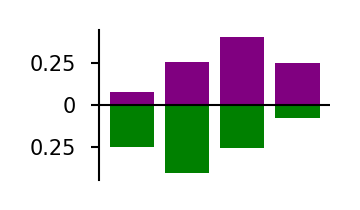

In [4]:
weakLLR = paramdict['midWS']['weakLLR']
WSratio = paramdict['midWS']['WSratio']
pdist1, pdist2 = utils.llr2probs_4shapes(llr=np.array([-weakLLR*WSratio, -weakLLR, weakLLR, weakLLR*WSratio]), p1=paramdict['midWS']['p1'])

fig, ax = plt.subplots(figsize=(1.3,0.8), dpi=300)

ax.bar(np.arange(4), pdist1, color='purple', label='state 1')

ax.bar(np.arange(4), -pdist2, color='green', label='state 2')
xlims = ax.get_xlim()
ax.plot(xlims, [0,0], color='black', linewidth=0.5)
ax.set_xlim(xlims)
ax.axes.get_xaxis().set_visible(False)
ax.set_yticks([-0.25, 0, 0.25])
ax.set_yticklabels(['0.25','0','0.25'])

format_axis(ax)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
savefig(fig, 'Figure1/figure1_likelihoods')
# plt.savefig(savedir+'Figure1/figure1_likelihoods.svg', bbox_inches='tight')

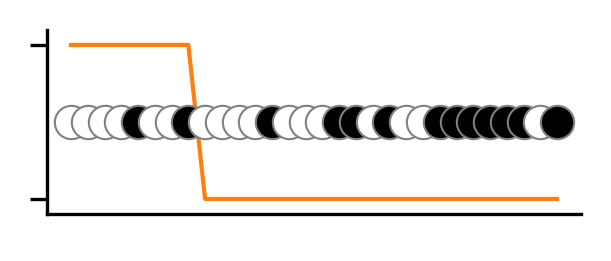

In [5]:
mfcs = {
    0: 'black',
    1: 'white'
}

mecs = {
    1: 'gray',
    0: 'gray'
}

cmap = plt.get_cmap("tab10")

fig = plt.figure(figsize=(2.3,0.8), dpi=300)
ax = fig.add_subplot(111)

ax.plot(jars_emp[55:85],c=cmap(1),linewidth=1)
for tt in range(55,85):
    ax.plot(tt-55,0.5,'o',markersize=8,markeredgewidth=0.5,mec=mecs[beads_emp_raw[tt]],mfc=mfcs[beads_emp_raw[tt]])
ax.set_ylim([-0.1,1.1])
ax.set_xticks([])
ax.set_yticks([0,1],labels=[])

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.8)

ax.tick_params(axis='x', labelsize=5, width=0.8, length=4)
ax.tick_params(axis='y', labelsize=5, width=0.8, length=4)
sns.despine()
# ax.spines['bottom'].set_linewidth(0.5)
# ax.spines['left'].set_linewidth(0.5)
savefig(fig, 'Figure1/figure1_bead_seq')

## Figure 2
Basic IB theoretical results and visual assets for the figure

In [49]:
# get IB bound (IB-optimal for true p(X,Y)) on the experimental trial set
shapes_Xset = utils.get_shapes_Xset()
p_XgY = utils.P_shapecomb_g_horse(shapes_Xset,paramdict['highWS']['weakLLR'],paramdict['highWS']['WSratio'],paramdict['highWS']['p1'])
emp_bound = utils.get_IB_bound_emp(shapes_emp_dict['highWS']['full'],shapes_Xset,horses_emp_dict['highWS'],p_XgY,p_Y,N_b=N_b_ib,max_b=max_b_ib,iterlimit=IB_iterlimit,N_threads=N_threads)

# get IB curve for softmax solution on the experimental trial set
p_YgX_emp = utils.P_horse_g_shapecomb(shapes_emp_dict['highWS']['full'],paramdict['highWS']['weakLLR'],paramdict['highWS']['WSratio'],paramdict['highWS']['p1'],p_Y=p_Y)
emp_softmax_curve = utils.get_softmax_IB_curve_emp(shapes_emp_dict['highWS']['full'],horses_emp_dict['highWS'],p_YgX_emp,N_b=N_b_softmax,max_b=max_b_softmax)

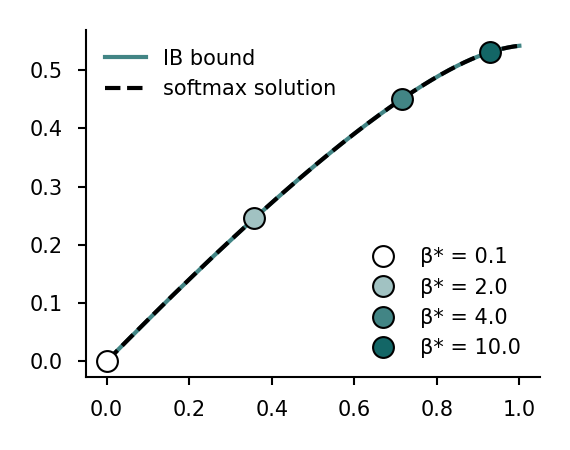

In [53]:
betastars = np.array([0.1, 2, 4, 10])

fig, ax = plt.subplots(figsize=(2,1.6), dpi=300)

ibbound, = ax.plot(emp_bound['I_XR'], emp_bound['I_RY'], label='IB bound', color=cmap_t(0.8), linewidth=1)
softmaxbound, = ax.plot(emp_softmax_curve['I_XR'], emp_softmax_curve['I_RY'], '--k',linewidth=1, label='softmax solution')

legend_handles = []
legend_labels = []
for ii, bb in enumerate(betastars):
    softmax_soln = utils.get_softmax_IB_emp(bb,shapes_emp_dict['highWS']['full'],horses_emp_dict['highWS'],p_YgX_emp,return_dict=True)
    if ii == 0:
        soln, = ax.plot(softmax_soln['I_XR'], softmax_soln['I_RY'],'o',c=cmap_t(1-get_color(ii,betastars,1,5)),markeredgecolor='k',markersize=5,markeredgewidth=0.5)
    else:
        soln, = ax.plot(softmax_soln['I_XR'], softmax_soln['I_RY'],'o',c=cmap_t(1-get_color(ii,betastars,0,5)),markeredgecolor='k',markersize=5,markeredgewidth=0.5)
    legend_handles.append(soln,)
    legend_labels.append(f'β* = {bb}')
format_axis(ax)
leg1 = ax.legend(legend_handles, legend_labels, fontsize=5, frameon=False, loc='lower right')
leg2 = ax.legend([ibbound, softmaxbound], ['IB bound', 'softmax solution'], fontsize=5, frameon=False, loc='upper left')
ax.add_artist(leg1)
plt.tight_layout()
savefig(fig, 'Figure2/figure2_IBbound')

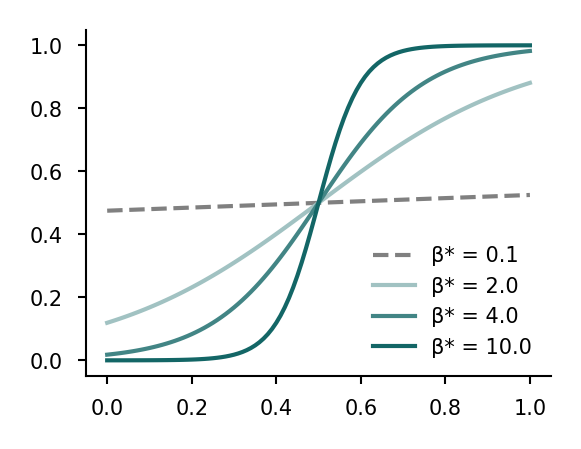

In [8]:
p = np.arange(0,1.01,0.01).reshape(-1,1)

legend_handles = []  
legend_labels = []

fig, ax = plt.subplots(figsize=(2,1.5), dpi=300)

for ii, bb in enumerate(betastars):
    curve = softmax(bb*np.concatenate((p,1-p),axis=1),axis=1)
    if ii == 0:
        line, = ax.plot(p, curve[:, 0],'--', c='gray', label=f'β* = {bb}',linewidth=1)
    else:
        line, = ax.plot(p,curve[:,0],c=cmap_t(1-get_color(ii,betastars,0,5)), label=f'β = {bb}',linewidth=1)
    legend_handles.append(line)
    legend_labels.append(f'β* = {bb}')
format_axis(ax)
ax.legend(legend_handles, legend_labels, fontsize=5, frameon=False, loc='lower right')
savefig(fig, 'Figure2/figure2_softmax_PFs')

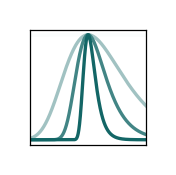

In [9]:
from scipy.stats import gumbel_r

fig, ax = plt.subplots(figsize=(0.5,0.5), dpi=300)

x = np.arange(-100,100,0.01)
p1 = 0.3
p2 = 0.7

for ii, bb in enumerate(betastars):
    iline2, = ax.plot(x/bb+p2,gumbel_r.pdf(x),c=cmap_t(1-get_color(ii,betastars,0,5)),linewidth=0.8)

ax.set_xlim([p2-1,p2+1])
ylim = ax.get_ylim()
ax.set_ylim(ylim)
ax.set_xticks([])
ax.set_xlabel('', fontsize=5)
ax.set_ylabel('', fontsize=5)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.spines['bottom'].set_linewidth(0.3)
ax.spines['left'].set_linewidth(0.3)
ax.spines['top'].set_linewidth(0.3)
ax.spines['right'].set_linewidth(0.3)
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)
savefig(fig, 'Figure2/figure2_gumbel')

In [10]:
# get equal-weights heuristic IB bound (IB-optimal for true p(X,Y)) on the experimental trial set
shapes_Xset_ew = utils.get_shapes_Xset(encoding='equal-weights')
p_XgY_ew = utils.P_shapecomb_g_horse_ew(shapes_Xset_ew,paramdict['highWS']['weakLLR'],paramdict['highWS']['WSratio'],paramdict['highWS']['p1'])
emp_bound_heur = utils.get_IB_bound_emp(shapes_emp_dict['highWS']['equal-weights'],shapes_Xset_ew,horses_emp_dict['highWS'],p_XgY_ew,p_Y,N_b=N_b_ib,max_b=max_b_ib,iterlimit=IB_iterlimit,N_threads=N_threads)

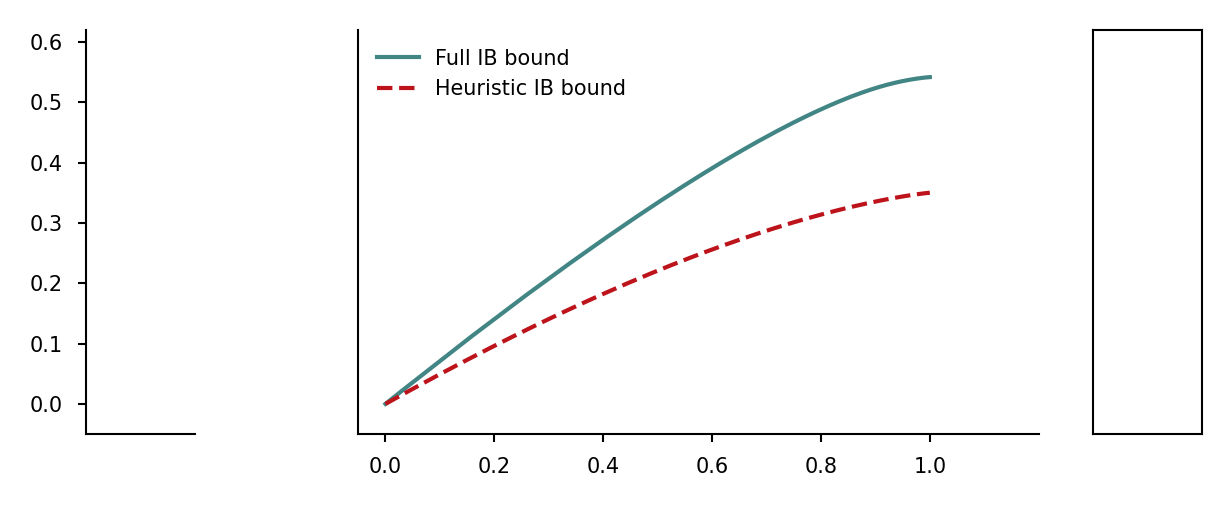

In [11]:
legend_handles = []  
legend_labels = []

# make x scale constant across both subplots
# Calculate width ratio based on x-limits
xlim_left = (0.2 - 0)  # width of left subplot
xlim_mid = (1.2 - (-0.05))  # width of right subplot
xlim_right = (0.2 - 0)  # width of right subplot
width_ratio = [xlim_left, xlim_mid, xlim_right]

# fig, axs = plt.subplots(1, 3, figsize=(4.5, 1.75), dpi=300, gridspec_kw={'width_ratios': width_ratio})
fig = plt.figure(figsize=(4.8, 1.75), dpi=300)

# Create GridSpec with 5 columns: [left_plot, gap1, middle_plot, gap2, right_plot]
# The gaps are just empty space columns
gs = gridspec.GridSpec(1, 5, figure=fig, 
                       width_ratios=[xlim_left, 0.3, xlim_mid, 0.1, xlim_right],
                       wspace=0)  # Set wspace to 0 since we're using gap columns

# Create subplots in non-gap columns
axs = [fig.add_subplot(gs[0, 0]),   # left subplot
       fig.add_subplot(gs[0, 2]),   # middle subplot  
       fig.add_subplot(gs[0, 4])]   # right subplot

axs[0].set_xlim(0,0.2)
axs[0].set_ylim(-0.05,0.62)
axs[0].set_xticks([])
format_axis(axs[0])

fullbound, = axs[1].plot(emp_bound['I_XR'],emp_bound['I_RY'],c=cmap_t(.8),linewidth=1,label='Full IB bound')
heurbound, = axs[1].plot(emp_bound_heur['I_XR'],emp_bound_heur['I_RY'],'--',c=cmap_r(.8),linewidth=1,label='Heuristic IB bound')

format_axis(axs[1])
axs[1].legend(fontsize=5, frameon=False)
axs[1].set_xlim(-0.05,1.2)
axs[1].set_xticks(np.arange(0,1.2,0.2))
axs[1].set_ylim(-0.05,0.62)
axs[1].set_yticks([])

axs[2].set_xlim(0,0.2)
axs[2].set_ylim(-0.05,0.62)
axs[2].set_xticks([])
axs[2].spines['left'].set_linewidth(0.5)
axs[2].spines['right'].set_linewidth(0.5)
axs[2].spines['top'].set_linewidth(0.5)
axs[2].spines['bottom'].set_linewidth(0.5)
axs[2].tick_params(axis='x', labelsize=5, width=0.5, length=2)
axs[2].tick_params(axis='y', labelsize=5, width=0.5, length=2)
axs[2].set_yticks([])
axs[2].set_xticks([])

savefig(fig, 'Figure2/figure2_data_schematic_template')

## Figure 3
IB-analyses of human behavior on the bead-prediction experiment

In [12]:
# compute empirical IB bound for the fully optimal strategy
beads_Xset = utils.get_beads_Xset(wsize)
p_XgY = utils.P_beads_g_jar(beads_Xset,E,H)
emp_bound_opt_beads = utils.get_IB_bound_emp(beads_emp, beads_Xset, jars_emp, p_XgY, p_Y, N_b=N_b_ib, max_b=max_b_ib, iterlimit=IB_iterlimit, N_threads=N_threads)

# compute empirical IB bound for the one-back heuristic strategy
beads_Xset_1b = utils.get_beads_Xset(wsize=1)
beads_emp_1b, jars_emp_1b = utils.getXY_beads(beads_emp_raw, jars_emp_raw, wsize=1)
p_XgY_1b = utils.P_beads_g_jar(beads_Xset_1b,E,H)
emp_bound_heur_beads = utils.get_IB_bound_emp(beads_emp_1b, beads_Xset_1b, jars_emp_1b, p_XgY_1b, p_Y, N_b=N_b_ib, max_b=max_b_ib, iterlimit=IB_iterlimit, N_threads=N_threads)

# compute empirical softmax curve for the fully optimal strategy
p_YgX = utils.P_jar_g_beads(beads_emp,E,H,p_Y)
emp_softmax_curve_opt_beads = utils.get_softmax_IB_curve_emp(beads_emp,jars_emp,p_YgX,N_b=N_b_softmax,max_b=max_b_softmax)

# compute empirical softmax curve for the one-back heuristic strategy
p_YgX_1b = utils.P_jar_g_beads(beads_emp_1b,E,H,p_Y)
emp_softmax_curve_heur_beads = utils.get_softmax_IB_curve_emp(beads_emp_1b,jars_emp_1b,p_YgX_1b,N_b=N_b_softmax,max_b=max_b_softmax)

In [13]:
p_RgX_opt = p_YgX.argmax(axis=1)
p_RgX_opt_oh = np.eye(2)[p_RgX_opt]
acc_opt = np.mean(p_RgX_opt == jars_emp)
I_RY_opt = utils.compute_I_RY_emp(p_RgX_opt_oh, jars_emp)
print(f"Optimal strategy accuracy: {acc_opt:.3f}, I(R;Y): {I_RY_opt:.3f}")

Optimal strategy accuracy: 0.939, I(R;Y): 0.664


### Compute IB measures for each run for each participant
And compute CI of $I(R;Y)$

In [14]:
# import preprocessed human behavioral data
datadf_beads = pd.read_csv(beads_datadir + "sj-preproc-data.csv")

if loaddataflag and os.path.exists(beads_datadir + "all-sj-analysis-data.csv"):
    ibdf_beads = pd.read_csv(beads_datadir + "sj-IB-measures.csv")
    alldata_beads = pd.read_csv(beads_datadir + "all-sj-analysis-data.csv")

else:

    ibdf_beads = pd.DataFrame({
        'subject_ID': [],
        'subject_index': [],
        'run': [],
        'Ixr': [],
        'Iry': [],
        'Iry_CI_lower': [],
        'Iry_CI_upper': []
    })

    Xemp, Yemp = utils.getXY_beads(beads_emp_raw, jars_emp_raw, wsize,encodeX=True)
    Xcard = 2**wsize
    Rcard = 2
    Ycard = 2

    sjlist = datadf_beads['subject_index'].unique()
    for ii,sj in enumerate(sjlist):
        for run in [1,2]:

            sjdf = pd.DataFrame({
                'subject_ID': [''],
                'subject_index': [np.nan],
                'run': [np.nan],
                'Ixr': [np.nan],
                'Iry': [np.nan],
                'Iry_CI_lower': [np.nan],
                'Iry_CI_upper': [np.nan]
            })

            df_ = datadf_beads[(datadf_beads['subject_index']==sj) & (datadf_beads['run']==run)]
            Remp = utils.getR_beads(df_['choice'].to_numpy(),wsize)

            # compute I(X;R) and I(R;Y) for this subject and run
            Ixr = utils.mutual_inf_nsb(Xemp,Remp,[Xcard,Rcard])
            Iry = utils.mutual_inf_nsb(Remp,Yemp,[Rcard,Ycard])

            # compute confidence interval for I(R;Y) for this subject and run
            Iry_CI = utils.get_Iry_CI(Remp,Yemp,CI,boot_iters,Rcard=Rcard,Ycard=Ycard,seed=234,N_threads=N_threads)

            sjdf['subject_ID'] = df_['subject_ID'].iloc[0]
            sjdf['subject_index'] = sj
            sjdf['run'] = run
            sjdf['Ixr'] = Ixr
            sjdf['Iry'] = Iry
            sjdf['Iry_CI_lower'] = Iry_CI[0]
            sjdf['Iry_CI_upper'] = Iry_CI[1]

            ibdf_beads = pd.concat((ibdf_beads, sjdf), ignore_index=True)

    # compute information efficiency for each subject and run
    ibdf_beads['info_efficiency'] = ibdf_beads['Iry'] / np.interp(ibdf_beads['Ixr'],emp_bound_opt_beads['I_XR'], emp_bound_opt_beads['I_RY'])
    ibdf_beads['info_efficiency_CI_lower'] = ibdf_beads['Iry_CI_lower'] / np.interp(ibdf_beads['Ixr'],emp_bound_opt_beads['I_XR'], emp_bound_opt_beads['I_RY'])
    ibdf_beads['info_efficiency_CI_upper'] = ibdf_beads['Iry_CI_upper'] / np.interp(ibdf_beads['Ixr'],emp_bound_opt_beads['I_XR'], emp_bound_opt_beads['I_RY'])

    # classify each subject and run according to which IB bound (fully optimal or heuristic) they are closest to, among those that are consistent with their confidence interval for I(R;Y)
    ibdf_beads['bound_class'] = utils.classify_by_bound(ibdf_beads['Ixr'], ibdf_beads['Iry'], ibdf_beads['Iry_CI_lower'], ibdf_beads['Iry_CI_upper'], [emp_bound_opt_beads, emp_bound_heur_beads], bound_labels=['full', '1back'])

    modeldf_beads = pd.read_csv(beads_datadir + 'model_fits.csv')
    alldata_beads = pd.merge(ibdf_beads, modeldf_beads, on=['subject_ID', 'subject_index', 'run'])
    if savedataflag:
        ibdf_beads.to_csv(beads_datadir + "sj-IB-measures.csv", index=False)
        alldata_beads.to_csv(beads_datadir + "all-sj-analysis-data.csv", index=False)

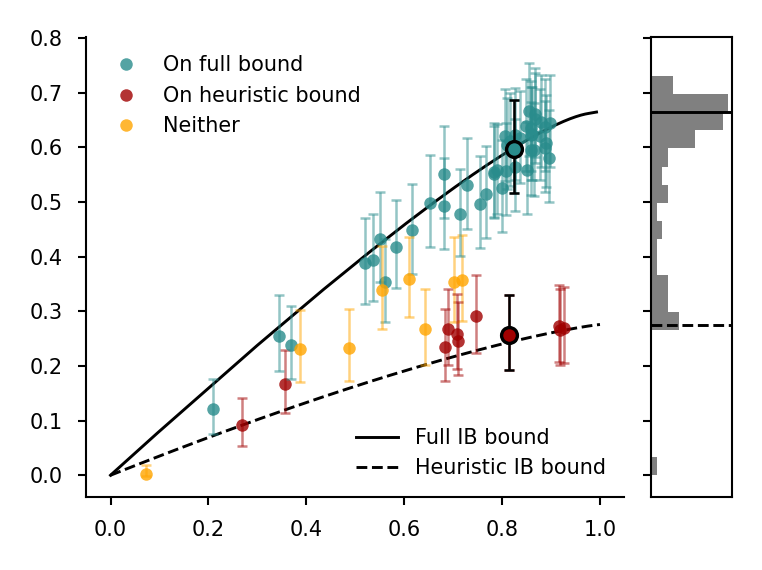

In [61]:
# plot subject data in IB space for run 2
# EXCLUDE those with I(X;R) < 0.05

highlighted_sjs = [6, 54]

alpha_dot = 0.8
alpha_line = 0.5

conds = (ibdf_beads['Ixr'] >= 0.05) & (ibdf_beads['run']==2)

fig, ax = plt.subplots(figsize=(2.7, 2), dpi=300)

full_bound, = ax.plot(emp_bound_opt_beads['I_XR'], emp_bound_opt_beads['I_RY'], 'k', linewidth=0.7, label='Full IB bound')
heur_bound, = ax.plot(emp_bound_heur_beads['I_XR'], emp_bound_heur_beads['I_RY'], '--k', linewidth=0.7, label='Heuristic IB bound')

for sjind in pd.unique(ibdf_beads[conds]['subject_index']):
    sjconds = conds & (ibdf_beads['subject_index'] == sjind)
    if ibdf_beads[sjconds]['bound_class'].to_numpy() == 'full':
        ax.errorbar(ibdf_beads[sjconds]['Ixr'], ibdf_beads[sjconds]['Iry'], yerr=[ibdf_beads[sjconds]['Iry'] - ibdf_beads[sjconds]['Iry_CI_lower'], ibdf_beads[sjconds]['Iry_CI_upper'] - ibdf_beads[sjconds]['Iry']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        onfullbound, = ax.plot(ibdf_beads[sjconds]['Ixr'],ibdf_beads[sjconds]['Iry'],'o',c=optcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On full bound')
    elif ibdf_beads[sjconds]['bound_class'].to_numpy() == '1back':
        ax.errorbar(ibdf_beads[sjconds]['Ixr'], ibdf_beads[sjconds]['Iry'], yerr=[ibdf_beads[sjconds]['Iry'] - ibdf_beads[sjconds]['Iry_CI_lower'], ibdf_beads[sjconds]['Iry_CI_upper'] - ibdf_beads[sjconds]['Iry']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        onheurbound, = ax.plot(ibdf_beads[sjconds]['Ixr'],ibdf_beads[sjconds]['Iry'],'o',c=heurcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On heuristic bound')
    elif ibdf_beads[sjconds]['bound_class'].to_numpy() == 'none':
        ax.errorbar(ibdf_beads[sjconds]['Ixr'], ibdf_beads[sjconds]['Iry'], yerr=[ibdf_beads[sjconds]['Iry'] - ibdf_beads[sjconds]['Iry_CI_lower'], ibdf_beads[sjconds]['Iry_CI_upper'] - ibdf_beads[sjconds]['Iry']], fmt='none', ecolor=nonecolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        other, = ax.plot(ibdf_beads[sjconds]['Ixr'],ibdf_beads[sjconds]['Iry'],'o',c=nonecolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='Neither')

high_color = 'black'
high_width = 0.8
high_alpha = 1.0
for sjind in highlighted_sjs:
    sjconds = conds & (ibdf_beads[conds]['subject_index'] == sjind)
    if ibdf_beads[sjconds]['bound_class'].to_numpy() == 'full':
        ax.errorbar(ibdf_beads[sjconds]['Ixr'], ibdf_beads[sjconds]['Iry'], yerr=[ibdf_beads[sjconds]['Iry'] - ibdf_beads[sjconds]['Iry_CI_lower'], ibdf_beads[sjconds]['Iry_CI_upper'] - ibdf_beads[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_beads[sjconds]['Ixr'],ibdf_beads[sjconds]['Iry'],'o',c=optcolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)
    elif ibdf_beads[sjconds]['bound_class'].to_numpy() == '1back':
        ax.errorbar(ibdf_beads[sjconds]['Ixr'], ibdf_beads[sjconds]['Iry'], yerr=[ibdf_beads[sjconds]['Iry'] - ibdf_beads[sjconds]['Iry_CI_lower'], ibdf_beads[sjconds]['Iry_CI_upper'] - ibdf_beads[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_beads[sjconds]['Ixr'],ibdf_beads[sjconds]['Iry'],'o',c=heurcolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)
    elif ibdf_beads[sjconds]['bound_class'].to_numpy() == 'none':
        ax.errorbar(ibdf_beads[sjconds]['Ixr'], ibdf_beads[sjconds]['Iry'], yerr=[ibdf_beads[sjconds]['Iry'] - ibdf_beads[sjconds]['Iry_CI_lower'], ibdf_beads[sjconds]['Iry_CI_upper'] - ibdf_beads[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_beads[sjconds]['Ixr'],ibdf_beads[sjconds]['Iry'],'o',c=nonecolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)

leg1 = ax.legend(handles=[onfullbound, onheurbound, other],fontsize=5, frameon=False, loc='upper left')
leg2 = ax.legend(handles=[full_bound, heur_bound],fontsize=5, frameon=False, loc='lower right')
ax.add_artist(leg1)

format_axis(ax)

Iry_interp_opt = np.interp(ibdf_beads.loc[conds,'Ixr'], emp_bound_opt_beads['I_XR'], emp_bound_opt_beads['I_RY'])
Iry_interp_1b = np.interp(ibdf_beads.loc[conds,'Ixr'], emp_bound_heur_beads['I_XR'], emp_bound_heur_beads['I_RY'])
relative_heur = Iry_interp_1b / Iry_interp_opt

avg_rel_1b = relative_heur.mean()
yvals_norm = ibdf_beads.loc[conds,'info_efficiency'].to_numpy() * emp_bound_opt_beads['I_RY'].max()
bins = (np.arange(0,1.2,0.05)) * emp_bound_opt_beads['I_RY'].max()
counts, bins = np.histogram(yvals_norm, bins=bins)

ax_hist = ax.inset_axes([1.05, 0, 0.15, 1], sharey=ax)
ax_hist.barh((bins[:-1] + bins[1:]) / 2, counts, height=(bins[1] - bins[0]), color='gray')
ax_hist.axhline(emp_bound_opt_beads['I_RY'].max(), color='black', linestyle='-', linewidth=0.7)
ax_hist.axhline(avg_rel_1b * emp_bound_opt_beads['I_RY'].max(), color='black', linestyle='--', linewidth=0.7)
# ax_hist.set_xlabel('Count')
ax_hist.set_ylabel('')
# ax_hist.set_yticks([])
ax_hist.tick_params(axis='y', labelleft=False, labelsize=5, width=0.5, length=2)
ax_hist.set_xticks([])
ax_hist.set_ylim(ax.get_ylim())
ax_hist.grid(False)
ax_hist.spines['bottom'].set_linewidth(0.5)
ax_hist.spines['left'].set_linewidth(0.5)
ax_hist.spines['top'].set_linewidth(0.5)
ax_hist.spines['right'].set_linewidth(0.5)
plt.tight_layout()
savefig(fig, 'Figure3/figure3_beads_IBplot')

In [57]:
# number of participants in each bound class for run 2
ibdf_beads[conds]['bound_class'].value_counts()

full     45
1back    11
none      8
Name: bound_class, dtype: int64

c:\Users\parja\Projects\human-inference-IB\utilities.py:865: RuntimeWarning: divide by zero encountered in log
  DKL = p_x * np.nansum(p_choice * np.log(p_choice / p_pred))
c:\Users\parja\Projects\human-inference-IB\utilities.py:865: RuntimeWarning: invalid value encountered in multiply
  DKL = p_x * np.nansum(p_choice * np.log(p_choice / p_pred))


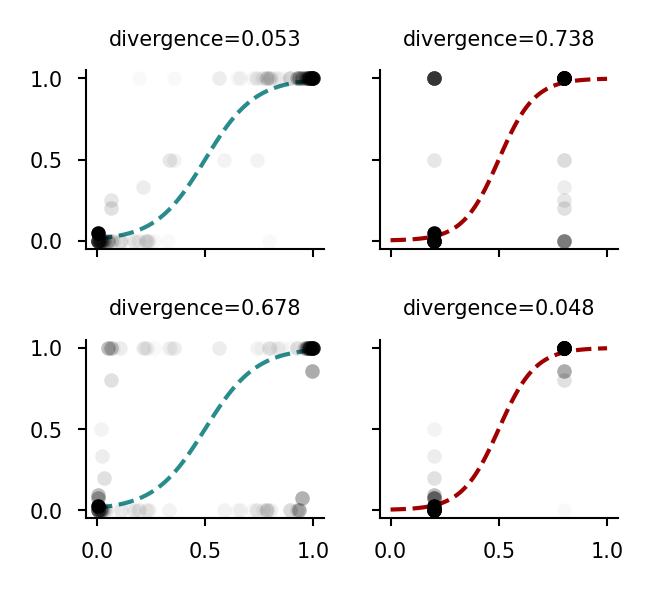

In [65]:
# psychometric functions for highlighted subjects, compared to IB-predicted psychometric functions for each bound (full and heuristic)

choicedf_beads = pd.read_csv(beads_datadir + 'sj-psychometric-data.csv')
postdf_beads = pd.read_csv(beads_datadir + 'strat-post-probs.csv')

fig, axs = plt.subplots(2,2, figsize=(2.3,2.05), dpi=300)

strats = ['fully-optimal','1-back']
strat_colors = {
    'fully-optimal': optcolor,
    '1-back': heurcolor
}
strat_bounds = {
    'fully-optimal': emp_softmax_curve_opt_beads,
    '1-back': emp_softmax_curve_heur_beads
}
conds1 = (choicedf_beads['run']==2)
conds2 = (ibdf_beads['run']==2)

for ii, sj in enumerate(highlighted_sjs):
    sjconds1 = conds1 & (choicedf_beads['subject_index'] == sj)
    sjconds2 = conds2 & (ibdf_beads['subject_index'] == sj)
    for jj, strat in enumerate(strats):
        utils.get_IB_predicted_psychometric_plot(ibdf_beads.loc[sjconds2,'Ixr'].values[0],strat_bounds[strat],strat_colors[strat],axs[ii,jj])
        utils.get_sj_psychometric_plot(choicedf_beads.loc[sjconds1], postdf_beads.loc[postdf_beads['strategy']==strat], axs[ii,jj])
        dkl = utils.get_psychometric_DKL(choicedf_beads.loc[sjconds1], postdf_beads.loc[postdf_beads['strategy']==strat],ibdf_beads.loc[sjconds2,'Ixr'].values[0],strat_bounds[strat])
        format_axis(axs[ii,jj])
        axs[ii,jj].set_title(f'divergence={dkl:.3f}', fontsize=5)
        if ii == 0:
            axs[ii,jj].set_xticklabels([])
        if jj == 1:
            axs[ii,jj].set_yticklabels([])
plt.tight_layout(pad=1)
savefig(fig, 'Figure3/figure3_beads_PMFs')

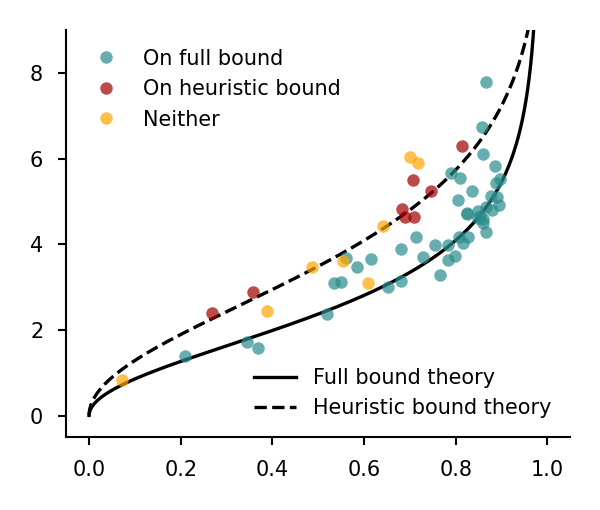

In [68]:
# plot choice noise term (best-fitting model betastar) vs I(X;R) for run 2
# EXCLUDE those with I(X;R) < 0.05

modeldf_beads = pd.read_csv(beads_datadir + 'model_fits.csv')
alldata_beads = pd.merge(ibdf_beads, modeldf_beads, on=['subject_ID', 'subject_index', 'run'])

conds = (alldata_beads['Ixr'] >= 0.05) & (alldata_beads['run']==2)

fig, ax = plt.subplots(figsize=(2.1, 1.8), dpi=300)

ib_theory, = ax.plot(emp_softmax_curve_opt_beads['I_XR'], emp_softmax_curve_opt_beads['betastar'], 'k', alpha=1,linewidth=0.8,label='Full bound theory')
heur_theory, = ax.plot(emp_softmax_curve_heur_beads['I_XR'], emp_softmax_curve_heur_beads['betastar'], '--k', alpha=1,linewidth=0.8,label='Heuristic bound theory')

for sjind in pd.unique(alldata_beads.loc[conds,'subject_index']):
    sjconds = conds & (alldata_beads['subject_index'] == sjind)
    if (alldata_beads.loc[conds & (alldata_beads['subject_index'] == sjind),'bound_class'].to_numpy() == 'full'):
        onfullbound, = ax.plot(alldata_beads.loc[sjconds,'Ixr'],alldata_beads.loc[sjconds,'best_model_betastar'],'o',c=optcolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On full bound')
    elif alldata_beads.loc[conds & (alldata_beads['subject_index'] == sjind),'bound_class'].to_numpy() == '1back':
        onheurbound, = ax.plot(alldata_beads.loc[sjconds,'Ixr'],alldata_beads.loc[sjconds,'best_model_betastar'],'o',c=heurcolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On heuristic bound')
    elif alldata_beads.loc[conds & (alldata_beads['subject_index'] == sjind),'bound_class'].to_numpy() == 'none':
        other, = ax.plot(alldata_beads.loc[sjconds,'Ixr'],alldata_beads.loc[sjconds,'best_model_betastar'],'o',c=nonecolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='Neither')
leg1 = ax.legend(handles=[onfullbound, onheurbound, other],fontsize=5, frameon=False, loc='upper left')
leg2 = ax.legend(handles=[ib_theory, heur_theory],fontsize=5, frameon=False, loc='lower right')
ax.add_artist(leg1)
ax.set_ylim(-0.5,9)
format_axis(ax)
plt.tight_layout()
savefig(fig, 'Figure3/figure3_beads_betastar_vs_Ixr')

## Figure 4
Model-fitting and comparision analyses for the bead-prediction experiment

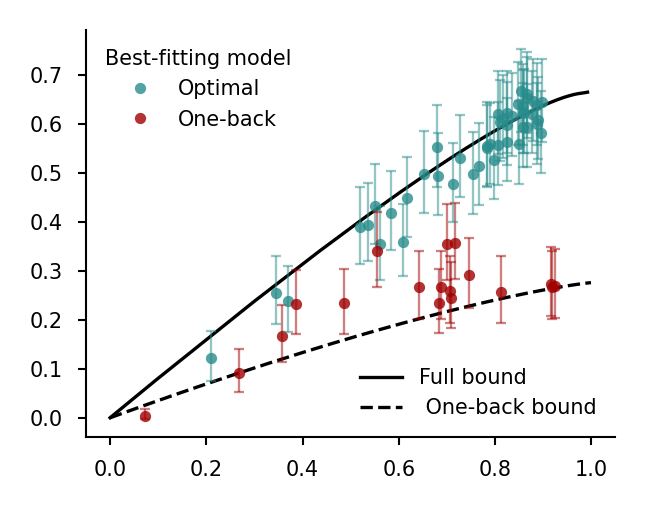

In [19]:
# plot subject data by IB space for run 2, colored by best-fitting model (optimal vs one-back)
# EXCLUDE those with I(X;R) < 0.05

alpha_dot = 0.8
alpha_line = 0.5

fig, ax = plt.subplots(figsize=(2.25, 1.8), dpi=300)

conds = (alldata_beads['run']==2) & (alldata_beads['Ixr'] >= 0.05)

fullbound, = ax.plot(emp_bound_opt_beads['I_XR'], emp_bound_opt_beads['I_RY'], 'k', alpha=1, linewidth=0.8, label='Full bound')
heurbound, = ax.plot(emp_bound_heur_beads['I_XR'], emp_bound_heur_beads['I_RY'],'--k',alpha=1,linewidth=0.8,label=' One-back bound')

for sjind in pd.unique(alldata_beads[conds]['subject_index']):
    sjconds = conds & (alldata_beads['subject_index']==sjind)
    if alldata_beads.loc[sjconds, 'opt_BIC'].iloc[0] < alldata_beads.loc[sjconds, 'oneback_BIC'].iloc[0]:
        ax.errorbar(alldata_beads[sjconds]['Ixr'], alldata_beads[sjconds]['Iry'], yerr=[alldata_beads[sjconds]['Iry'] - alldata_beads[sjconds]['Iry_CI_lower'], alldata_beads[sjconds]['Iry_CI_upper'] - alldata_beads[sjconds]['Iry']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.55, capsize=1.1, capthick=0.55)
        ibopt, = ax.plot(alldata_beads[sjconds]['Ixr'],alldata_beads[sjconds]['Iry'],'o',c=optcolor,alpha=alpha_dot,markersize=2.7,markeredgewidth=0,markeredgecolor='none',label='Optimal')
    else:
        ax.errorbar(alldata_beads[sjconds]['Ixr'], alldata_beads[sjconds]['Iry'], yerr=[alldata_beads[sjconds]['Iry'] - alldata_beads[sjconds]['Iry_CI_lower'], alldata_beads[sjconds]['Iry_CI_upper'] - alldata_beads[sjconds]['Iry']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.55, capsize=1.1, capthick=0.55)
        oneback, = ax.plot(alldata_beads[sjconds]['Ixr'],alldata_beads[sjconds]['Iry'],'o',c=heurcolor,alpha=alpha_dot,markersize=2.7,markeredgewidth=0,markeredgecolor='none',label='One-back')

format_axis(ax)
leg1 = ax.legend(handles=[ibopt, oneback], fontsize=5, title='Best-fitting model', title_fontsize=5, frameon=False, loc='best')
leg2 = ax.legend(handles=[fullbound, heurbound], fontsize=5, frameon=False, loc='lower right')
ax.add_artist(leg1)
plt.tight_layout()
savefig(fig, 'Figure4/figure4_beads_two-model-comparison')

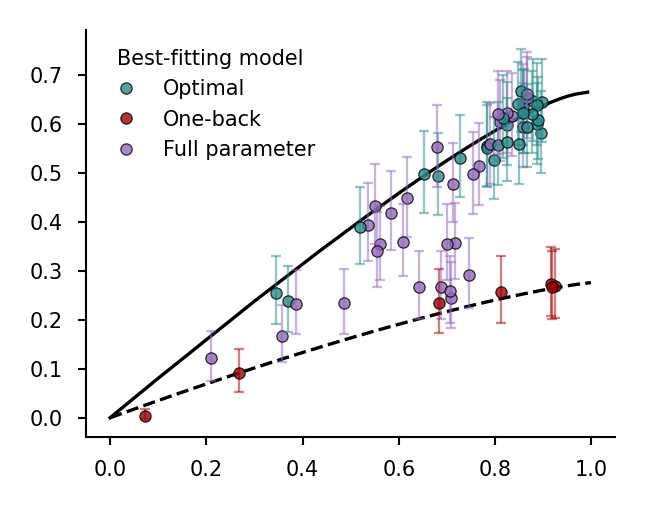

In [20]:
# plot subject data by IB space for run 2, colored by best-fitting model (optimal vs one-back vs full parameter)
# EXCLUDE those with I(X;R) < 0.05

alpha_dot = 0.8
alpha_line = 0.5
mew = 0.3
mec = 'k'

fig, ax = plt.subplots(figsize=(2.25, 1.8), dpi=300)

conds = (alldata_beads['run']==2) & (alldata_beads['Ixr'] >= 0.05)

fullbound, = ax.plot(emp_bound_opt_beads['I_XR'], emp_bound_opt_beads['I_RY'], 'k', alpha=1, linewidth=0.8, label='Full bound')
heurbound, = ax.plot(emp_bound_heur_beads['I_XR'], emp_bound_heur_beads['I_RY'],'--k',alpha=1,linewidth=0.8,label=' One-back bound')

for sjind in pd.unique(alldata_beads[conds]['subject_index']):
    sjconds = conds & (alldata_beads['subject_index']==sjind)
    if alldata_beads.loc[sjconds, 'best_model'].iloc[0] == 'fully_optimal':
        ax.errorbar(alldata_beads[sjconds]['Ixr'], alldata_beads[sjconds]['Iry'], yerr=[alldata_beads[sjconds]['Iry'] - alldata_beads[sjconds]['Iry_CI_lower'], alldata_beads[sjconds]['Iry_CI_upper'] - alldata_beads[sjconds]['Iry']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.55, capsize=1.1, capthick=0.55)
        ibopt, = ax.plot(alldata_beads[sjconds]['Ixr'],alldata_beads[sjconds]['Iry'],'o',c=optcolor,alpha=alpha_dot,markersize=2.7,markeredgewidth=mew,markeredgecolor=mec,label='Optimal')
    elif alldata_beads.loc[sjconds, 'best_model'].iloc[0] == 'oneback':
        ax.errorbar(alldata_beads[sjconds]['Ixr'], alldata_beads[sjconds]['Iry'], yerr=[alldata_beads[sjconds]['Iry'] - alldata_beads[sjconds]['Iry_CI_lower'], alldata_beads[sjconds]['Iry_CI_upper'] - alldata_beads[sjconds]['Iry']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.55, capsize=1.1, capthick=0.55)
        oneback, = ax.plot(alldata_beads[sjconds]['Ixr'],alldata_beads[sjconds]['Iry'],'o',c=heurcolor,alpha=alpha_dot,markersize=2.7,markeredgewidth=mew,markeredgecolor=mec,label='One-back')
    elif alldata_beads.loc[sjconds, 'best_model'].iloc[0] == 'fullparam':
        ax.errorbar(alldata_beads[sjconds]['Ixr'], alldata_beads[sjconds]['Iry'], yerr=[alldata_beads[sjconds]['Iry'] - alldata_beads[sjconds]['Iry_CI_lower'], alldata_beads[sjconds]['Iry_CI_upper'] - alldata_beads[sjconds]['Iry']], fmt='none', ecolor=fullparamcolor, alpha=alpha_line, linewidth=0.55, capsize=1.1, capthick=0.55)
        hmodel, = ax.plot(alldata_beads[sjconds]['Ixr'],alldata_beads[sjconds]['Iry'],'o',c=fullparamcolor,alpha=alpha_dot,markersize=2.7,markeredgewidth=mew,markeredgecolor=mec,label='Full parameter')
    
format_axis(ax)
leg1 = ax.legend(handles=[ibopt, oneback, hmodel], fontsize=5, title='Best-fitting model', title_fontsize=5, frameon=False, loc='best')
plt.tight_layout()
savefig(fig, 'Figure4/figure4_beads_all-model-comparison')

In [69]:
# number of participants in each best-fitting model class for run 2, grouped by IB bound class
alldata_beads.loc[conds].groupby('bound_class')['best_model'].value_counts()

bound_class  best_model   
1back        oneback           6
             fullparam         5
full         fully_optimal    26
             fullparam        19
none         fullparam         7
             oneback           1
Name: best_model, dtype: int64

In [22]:
# def get_efficiency_vs_parameter(target_param_vals,Ixr_param_vals,P_RgX_fn,Xemp,Yemp,Ixr_vals,opt_bound):
#     efficiencies = []
#     for param_val in target_param_vals:
#         P_RgX_fn_ = lambda Ixr_param_val: P_RgX_fn(param_val, Ixr_param_val)
#         ibcurve = utils.get_general_IB_curve_emp(Ixr_param_vals,Xemp,Yemp,P_RgX_fn_)
#         Iry_curve = np.interp(Ixr_vals, ibcurve['I_XR'], ibcurve['I_RY'])
#         Iry_opt = np.interp(Ixr_vals,opt_bound['I_XR'], opt_bound['I_RY'])
#         efficiencies.append(np.mean(Iry_curve / Iry_opt))
#     return efficiencies

h_vals = np.arange(0,1.01,0.01)
betastar_vals = np.linspace(max_b_softmax/N_b_softmax,max_b_softmax,N_b_softmax)

def fullparam_model(h,betastar):
    H_ = np.ones((2,2)) - np.abs(np.eye(2)*-1 + h) # transition matrix
    p_YgX_fullparam = utils.P_jar_g_beads(beads_emp,E,H_,P0)
    return softmax(betastar*p_YgX_fullparam, axis=1)

conds = (alldata_beads['run']==2) & (alldata_beads['Ixr'] >= 0.05)
Ixr_vals = alldata_beads.loc[conds,'Ixr'].to_numpy()

h_efficiencies = utils.get_efficiency_vs_parameter_curve(h_vals,betastar_vals,fullparam_model,beads_emp,jars_emp,Ixr_vals,emp_bound_opt_beads)

C:\Users\parja\AppData\Local\Temp\ipykernel_42288\2806141495.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


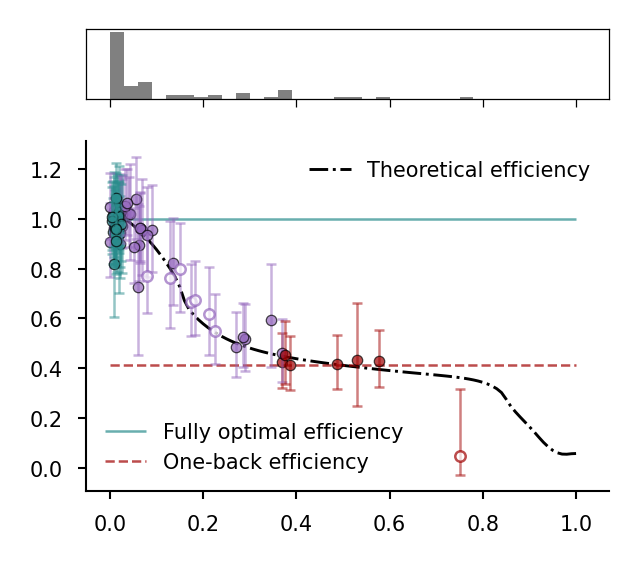

In [23]:
# plot efficiency curve as a function of hazard rate parameter (full-parameter model), both theoretical relationship and subject data, for run 2
# EXCLUDE those with I(X;R) < 0.05

alpha_dot = 0.8
alpha_line = 0.5
mew = 0.3
mec = 'k'
ms = 2.5

bins = np.arange(0,1.03,0.03)

Iry_interp_opt = np.interp(alldata_beads.loc[conds,'Ixr'], emp_bound_opt_beads['I_XR'], emp_bound_opt_beads['I_RY'])
Iry_interp_1b = np.interp(alldata_beads.loc[conds,'Ixr'], emp_bound_heur_beads['I_XR'], emp_bound_heur_beads['I_RY'])
relative_heur = Iry_interp_1b / Iry_interp_opt
avg_rel_1b = relative_heur.mean()

fig = plt.figure(figsize=(2.25, 2), dpi=300)

gs = gridspec.GridSpec(2, 1, height_ratios=[1, 5], hspace=0.2)

axs = []
axs.append(fig.add_subplot(gs[0]))
axs.append(fig.add_subplot(gs[1],sharex=axs[0]))

# fig, ax = plt.subplots(figsize=(2.5, 2), dpi=300)

conds = (alldata_beads['run']==2) & (alldata_beads['Ixr'] >= 0.05)

infoeff, = axs[1].plot(1-h_vals, h_efficiencies, '-.', linewidth=0.7, color='black',label='Theoretical efficiency', alpha=1)

highlighted_sjs = alldata_beads.loc[conds & (alldata_beads['bound_class']=='none'),'subject_index'].tolist()
other_sjs = alldata_beads.loc[conds & (alldata_beads['bound_class']!='none'),'subject_index'].tolist()

opteff = axs[1].hlines(y=1, xmin=0, xmax=1, colors=optcolor, linewidth=0.6, alpha=0.7,label='Fully optimal efficiency')
onebackeff = axs[1].hlines(y=avg_rel_1b, xmin=0, xmax=1, colors=heurcolor, linestyles='--', linewidth=0.6, alpha=0.7,label='One-back efficiency')

for sjind in other_sjs:
    sjconds = conds & (alldata_beads['subject_index']==sjind)
    if alldata_beads.loc[sjconds,'best_model'].iloc[0] == 'fully_optimal':
        axs[1].errorbar(1-alldata_beads.loc[sjconds,'fullparam_h'], alldata_beads.loc[sjconds,'info_efficiency'], yerr=[alldata_beads.loc[sjconds,'info_efficiency'] - alldata_beads.loc[sjconds,'info_efficiency_CI_lower'], alldata_beads.loc[sjconds,'info_efficiency_CI_upper'] - alldata_beads.loc[sjconds,'info_efficiency']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        ibopt, = axs[1].plot(1-alldata_beads.loc[sjconds,'fullparam_h'], alldata_beads.loc[sjconds,'info_efficiency'].to_numpy(), 'o', color=optcolor, alpha=0.7, markeredgecolor=mec, markeredgewidth=mew, markersize=ms, label='IB optimal')
    elif alldata_beads.loc[sjconds,'best_model'].iloc[0] == 'oneback':
        axs[1].errorbar(1-alldata_beads.loc[sjconds,'fullparam_h'], alldata_beads.loc[sjconds,'info_efficiency'], yerr=[alldata_beads.loc[sjconds,'info_efficiency'] - alldata_beads.loc[sjconds,'info_efficiency_CI_lower'], alldata_beads.loc[sjconds,'info_efficiency_CI_upper'] - alldata_beads.loc[sjconds,'info_efficiency']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        oneback, = axs[1].plot(1-alldata_beads.loc[sjconds,'fullparam_h'], alldata_beads.loc[sjconds,'info_efficiency'].to_numpy(), 'o', color=heurcolor, alpha=0.7, markeredgecolor=mec, markeredgewidth=mew, markersize=ms, label='One-back')
    elif alldata_beads.loc[sjconds,'best_model'].iloc[0] == 'fullparam':
        axs[1].errorbar(1-alldata_beads.loc[sjconds,'fullparam_h'], alldata_beads.loc[sjconds,'info_efficiency'], yerr=[alldata_beads.loc[sjconds,'info_efficiency'] - alldata_beads.loc[sjconds,'info_efficiency_CI_lower'], alldata_beads.loc[sjconds,'info_efficiency_CI_upper'] - alldata_beads.loc[sjconds,'info_efficiency']], fmt='none', ecolor=fullparamcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        hmodel, = axs[1].plot(1-alldata_beads.loc[sjconds,'fullparam_h'], alldata_beads.loc[sjconds,'info_efficiency'].to_numpy(), 'o', color=fullparamcolor, alpha=0.7, markeredgecolor=mec, markeredgewidth=mew, markersize=ms, label='Full parameter')

for sjind in highlighted_sjs:
    sjconds = conds & (alldata_beads['subject_index']==sjind)
    if alldata_beads.loc[sjconds,'best_model'].iloc[0] == 'fully_optimal':
        axs[1].errorbar(1-alldata_beads.loc[sjconds,'fullparam_h'], alldata_beads.loc[sjconds,'info_efficiency'], yerr=[alldata_beads.loc[sjconds,'info_efficiency'] - alldata_beads.loc[sjconds,'info_efficiency_CI_lower'], alldata_beads.loc[sjconds,'info_efficiency_CI_upper'] - alldata_beads.loc[sjconds,'info_efficiency']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        axs[1].plot(1-alldata_beads.loc[sjconds,'fullparam_h'], alldata_beads.loc[sjconds,'info_efficiency'].to_numpy(), 'o', color='white', alpha=0.7, markeredgecolor=optcolor, markeredgewidth=0.6, markersize=ms, label='IB optimal')
    elif alldata_beads.loc[sjconds,'best_model'].iloc[0] == 'oneback':
        axs[1].errorbar(1-alldata_beads.loc[sjconds,'fullparam_h'], alldata_beads.loc[sjconds,'info_efficiency'], yerr=[alldata_beads.loc[sjconds,'info_efficiency'] - alldata_beads.loc[sjconds,'info_efficiency_CI_lower'], alldata_beads.loc[sjconds,'info_efficiency_CI_upper'] - alldata_beads.loc[sjconds,'info_efficiency']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        axs[1].plot(1-alldata_beads.loc[sjconds,'fullparam_h'], alldata_beads.loc[sjconds,'info_efficiency'].to_numpy(), 'o', color='white', alpha=0.7, markeredgecolor=heurcolor, markeredgewidth=0.6, markersize=ms, label='One-back')
    elif alldata_beads.loc[sjconds,'best_model'].iloc[0] == 'fullparam':
        axs[1].errorbar(1-alldata_beads.loc[sjconds,'fullparam_h'], alldata_beads.loc[sjconds,'info_efficiency'], yerr=[alldata_beads.loc[sjconds,'info_efficiency'] - alldata_beads.loc[sjconds,'info_efficiency_CI_lower'], alldata_beads.loc[sjconds,'info_efficiency_CI_upper'] - alldata_beads.loc[sjconds,'info_efficiency']], fmt='none', ecolor=fullparamcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        axs[1].plot(1-alldata_beads.loc[sjconds,'fullparam_h'], alldata_beads.loc[sjconds,'info_efficiency'].to_numpy(), 'o', color='white', alpha=0.7, markeredgecolor=fullparamcolor, markeredgewidth=0.6, markersize=ms, label='Full parameter')

format_axis(axs[1])
leg1 = axs[1].legend(handles=[opteff, onebackeff], fontsize=5, frameon=False, loc='lower left')
leg2 = axs[1].legend(handles=[infoeff], fontsize=5, frameon =False, loc='upper right')
axs[1].add_artist(leg1)

sj_hvals = 1 - alldata_beads.loc[conds,'fullparam_h'].to_numpy()
x_counts, x_bins = np.histogram(sj_hvals, bins=bins)

axs[0].bar((x_bins[:-1] + x_bins[1:]) / 2, x_counts, width=(x_bins[1] - x_bins[0]), color='gray')
axs[0].grid(False)
axs[0].tick_params(axis='y', labelleft=False)
axs[0].tick_params(axis='x', labelbottom=False)
axs[0].spines['top'].set_linewidth(0.3)
axs[0].spines['right'].set_linewidth(0.3)
axs[0].spines['bottom'].set_linewidth(0.3)
axs[0].spines['left'].set_linewidth(0.3)
axs[0].tick_params(axis='x', labelsize=5, width=0.3, length=2)
axs[0].tick_params(axis='y', labelsize=5, width=0.3, length=2)
axs[0].set_yticks([])

plt.tight_layout()
savefig(fig, 'Figure4/figure4_beads_efficiency-vs-h-fits')

## Figure 5
IB-analyses of human behavior on the horse prediction experiments

In [24]:
if loaddataflag and os.path.exists(horses_datadir + 'IB_bounds.pkl'):
    with open(horses_datadir + 'IB_bounds.pkl', 'rb') as f:
        dat = pickle.load(f)
        bound_dict_horses = dat['bound_dict_horses']
        softmax_dict_horses = dat['softmax_dict_horses']
else:

    conds = ['lowWS','midWS','highWS']
    strats = ['full','equal-weights','ignore-weak']

    P_XgY_dict = {
        'full': utils.P_shapecomb_g_horse,
        'equal-weights': utils.P_shapecomb_g_horse_ew,
        'ignore-weak': utils.P_shapecomb_g_horse_iw
    }

    Xset_dict = {
        'full': utils.get_shapes_Xset(),
        'equal-weights': utils.get_shapes_Xset(encoding='equal-weights'),
        'ignore-weak': utils.get_shapes_Xset(encoding='ignore-weak')
    }

    # shapes_Xset = utils.get_shapes_Xset()

    p_XgY_dict = {}
    for cond in conds:
        p_XgY_dict[cond] = {}
        for strat in strats:
            p_XgY_dict[cond][strat] = P_XgY_dict[strat](Xset_dict[strat],paramdict[cond]['weakLLR'],paramdict[cond]['WSratio'],paramdict[cond]['p1'])

    bound_dict_horses = {}
    for cond in conds:
        bound_dict_horses[cond] = {}
        for strat in strats:
            bound_dict_horses[cond][strat] = utils.get_IB_bound_emp(shapes_emp_dict[cond][strat],Xset_dict[strat],horses_emp_dict[cond],p_XgY_dict[cond][strat],p_Y,N_b=N_b_ib,max_b=max_b_ib,iterlimit=IB_iterlimit,N_threads=N_threads)

    softmax_dict_horses = {}
    for cond in conds:
        softmax_dict_horses[cond] = {}
        for strat in strats:
            p_YgX_emp = utils.P_horse_g_shapecomb(shapes_emp_dict[cond][strat],paramdict[cond]['weakLLR'],paramdict[cond]['WSratio'],paramdict[cond]['p1'],p_Y=p_Y, P_XgY=P_XgY_dict[strat])
            softmax_dict_horses[cond][strat] = utils.get_softmax_IB_curve_emp(shapes_emp_dict[cond][strat],horses_emp_dict[cond],p_YgX_emp,N_b=N_b_softmax,max_b=max_b_softmax)

    if savedataflag:
        with open(horses_datadir + 'IB_bounds.pkl', 'wb') as f:
            pickle.dump({
                'bound_dict_horses': bound_dict_horses,
                'softmax_dict_horses': softmax_dict_horses
            }, f)

### Compute IB measures for each run for each participant (and for each experiment)
And compute CI of $I(R;Y)$

In [25]:
if loaddataflag and os.path.exists(horses_datadir + "lowWS/all-sj-analysis-data.csv"):
    ibdf_dict = {}
    ibdf_dict['lowWS'] = pd.read_csv(horses_datadir + "lowWS/sj-IB-measures.csv")
    ibdf_dict['midWS'] = pd.read_csv(horses_datadir + "midWS_learning/midWS_sj-IB-measures.csv")
    ibdf_dict['highWS'] = pd.read_csv(horses_datadir + "highWS/sj-IB-measures.csv")
    ibdf_dict['learning'] = pd.read_csv(horses_datadir + "midWS_learning/learning_sj-IB-measures.csv")
    ibdf_dict['reward'] = pd.read_csv(horses_datadir + "reward/sj-IB-measures.csv")
    ibdf_dict['speed_accuracy'] = pd.read_csv(horses_datadir + "speed_accuracy/sj-IB-measures.csv")

    alldata_dict = {}
    alldata_dict['lowWS'] = pd.read_csv(horses_datadir + "lowWS/all-sj-analysis-data.csv")
    alldata_dict['midWS'] = pd.read_csv(horses_datadir + "midWS_learning/midWS_all-sj-analysis-data.csv")
    alldata_dict['highWS'] = pd.read_csv(horses_datadir + "highWS/all-sj-analysis-data.csv")
    alldata_dict['learning'] = pd.read_csv(horses_datadir + "midWS_learning/learning_all-sj-analysis-data.csv")
    alldata_dict['reward'] = pd.read_csv(horses_datadir + "reward/all-sj-analysis-data.csv")
    alldata_dict['speed_accuracy'] = pd.read_csv(horses_datadir + "speed_accuracy/all-sj-analysis-data.csv")
else:
    exps1 = ['lowWS','midWS','highWS']
    exps2 = ['learning','reward','speed_accuracy']
    conds_dict = {
        'learning': ['run_1', 'run_2'],
        'reward': ['low_reward', 'high_reward'],
        'speed_accuracy': ['fast', 'slow']
    }

    preproc_dict = {
        'lowWS': pd.read_csv(horses_datadir + "lowWS/sj-preproc-data.csv"),
        'midWS': pd.read_csv(horses_datadir + "midWS_learning/sj-preproc-data.csv"),
        'highWS': pd.read_csv(horses_datadir + "highWS/sj-preproc-data.csv"),
        'learning': pd.read_csv(horses_datadir + "midWS_learning/sj-preproc-data.csv"),
        'reward': pd.read_csv(horses_datadir + "reward/sj-preproc-data.csv"),
        'speed_accuracy': pd.read_csv(horses_datadir + "speed_accuracy/sj-preproc-data.csv")
    }

    modeldf_dict = {
        'lowWS': pd.read_csv(horses_datadir + "lowWS/model_fits.csv"),
        'midWS': pd.read_csv(horses_datadir + "midWS_learning/midWS_model_fits.csv"),
        'highWS': pd.read_csv(horses_datadir + "highWS/model_fits.csv"),
        'learning': pd.read_csv(horses_datadir + "midWS_learning/learning_model_fits.csv"),
        'reward': pd.read_csv(horses_datadir + "reward/model_fits.csv"),
        'speed_accuracy': pd.read_csv(horses_datadir + "speed_accuracy/model_fits.csv")
    }

    ibdf_dict = {}
    alldata_dict = {}

    Xcard = 56 # number of unique shape combinations for five samples from four shapes (with replacement)
    Rcard = 2
    Ycard = 2

    # in this loop, all trials for the mid-WS/learning experiment (mid-WS) are included, but not separated by run (since lack of group learning effect, see paper)
    for exp in exps1:
        ibdf_ = pd.DataFrame({
            'subject_ID': [],
            'subject_index': [],
            'exclude_Ixr': [],
            'Ixr': [],
            'Iry': [],
            'Iry_CI_lower': [],
            'Iry_CI_upper': []
        })
        sjlist = preproc_dict[exp]['subject_index'].unique()
        for ii,sj in enumerate(sjlist):
            sjconds = (preproc_dict[exp]['subject_index'] == sj)
            shapes_emp = preproc_dict[exp][sjconds]['observation_encoding'].to_numpy()
            horses_emp = preproc_dict[exp][sjconds]['latent_state'].to_numpy()
            choices = preproc_dict[exp][sjconds]['choice'].to_numpy()

            # compute I(X;R) and I(R;Y) for this subject and run
            Ixr = utils.mutual_inf_nsb(shapes_emp, choices, [Xcard, Rcard])
            Iry = utils.mutual_inf_nsb(choices, horses_emp, [Rcard, Ycard])

            # compute confidence interval for I(R;Y) for this subject and run
            Iry_CI = utils.get_Iry_CI(choices, horses_emp, CI, boot_iters, Rcard=Rcard, Ycard=Ycard, seed=234, N_threads=N_threads)

            if exp == 'midWS':
                exclude_Ixr = int(Ixr < 0.05)
            else:
                exclude_Ixr = int(preproc_dict[exp][sjconds]['exclude_Ixr'].iloc[0])

            sjdf = pd.DataFrame({
                'subject_ID': [preproc_dict[exp][sjconds]['subject_ID'].iloc[0]],
                'subject_index': [sj],
                'exclude_Ixr': [exclude_Ixr],
                'Ixr': [Ixr],
                'Iry': [Iry],
                'Iry_CI_lower': [Iry_CI[0]],
                'Iry_CI_upper': [Iry_CI[1]]
            })
            ibdf_ = pd.concat((ibdf_, sjdf), ignore_index=True)

        # compute information efficiency for each subject and run
        ibdf_['info_efficiency'] = ibdf_['Iry'] / np.interp(ibdf_['Ixr'],bound_dict_horses[exp]['full']['I_XR'], bound_dict_horses[exp]['full']['I_RY'])
        ibdf_['info_efficiency_CI_lower'] = ibdf_['Iry_CI_lower'] / np.interp(ibdf_['Ixr'],bound_dict_horses[exp]['full']['I_XR'], bound_dict_horses[exp]['full']['I_RY'])
        ibdf_['info_efficiency_CI_upper'] = ibdf_['Iry_CI_upper'] / np.interp(ibdf_['Ixr'],bound_dict_horses[exp]['full']['I_XR'], bound_dict_horses[exp]['full']['I_RY'])

        # classify each subject and run according to which IB bound (fully optimal or heuristic) they are closest to, among those that are consistent with their confidence interval for I(R;Y)
        ibdf_['bound_class'] = utils.classify_by_bound(ibdf_['Ixr'], ibdf_['Iry'], ibdf_['Iry_CI_lower'], ibdf_['Iry_CI_upper'], [bound_dict_horses[exp]['full'], bound_dict_horses[exp]['equal-weights']], bound_labels=['full', 'equal-weights'])

        ibdf_dict[exp] = ibdf_.copy()
        alldata_dict[exp] = pd.merge(ibdf_, modeldf_dict[exp], on=['subject_ID', 'subject_index'])

    # in this loop, trials for the mid-WS/learning experiment are grouped by run for examination learning/repetition effects
    for exp in exps2:
        ibdf_ = pd.DataFrame({
            'subject_ID': [],
            'subject_index': [],
            'exclude_Ixr': [],
            'condition': [],
            'Ixr': [],
            'Iry': [],
            'Iry_CI_lower': [],
            'Iry_CI_upper': []
        })
        sjlist = preproc_dict[exp]['subject_index'].unique()
        for ii,sj in enumerate(sjlist):
            for jj in range(len(conds_dict[exp])):
                sjconds = (preproc_dict[exp]['subject_index'] == sj) & (preproc_dict[exp]['condition'] == conds_dict[exp][jj])
                shapes_emp = preproc_dict[exp][sjconds]['observation_encoding'].to_numpy()
                horses_emp = preproc_dict[exp][sjconds]['latent_state'].to_numpy()
                choices = preproc_dict[exp][sjconds]['choice'].to_numpy()

                # compute I(X;R) and I(R;Y) for this subject and run
                Ixr = utils.mutual_inf_nsb(shapes_emp, choices, [Xcard, Rcard])
                Iry = utils.mutual_inf_nsb(choices, horses_emp, [Rcard, Ycard])

                # compute confidence interval for I(R;Y) for this subject and run
                Iry_CI = utils.get_Iry_CI(choices, horses_emp, CI, boot_iters, Rcard=Rcard, Ycard=Ycard, seed=234, N_threads=N_threads)

                sjdf = pd.DataFrame({
                    'subject_ID': [preproc_dict[exp][sjconds]['subject_ID'].iloc[0]],
                    'subject_index': [sj],
                    'exclude_Ixr': [preproc_dict[exp][sjconds]['exclude_Ixr'].iloc[0]],
                    'condition': [conds_dict[exp][jj]],
                    'Ixr': [Ixr],
                    'Iry': [Iry],
                    'Iry_CI_lower': [Iry_CI[0]],
                    'Iry_CI_upper': [Iry_CI[1]]
                })
                ibdf_ = pd.concat((ibdf_, sjdf), ignore_index=True)

        # compute information efficiency for each subject and run
        ibdf_['info_efficiency'] = ibdf_['Iry'] / np.interp(ibdf_['Ixr'],bound_dict_horses['midWS']['full']['I_XR'], bound_dict_horses['midWS']['full']['I_RY']) # all these experiments use the intermidate WS trial set
        ibdf_['info_efficiency_CI_lower'] = ibdf_['Iry_CI_lower'] / np.interp(ibdf_['Ixr'],bound_dict_horses['midWS']['full']['I_XR'], bound_dict_horses['midWS']['full']['I_RY'])
        ibdf_['info_efficiency_CI_upper'] = ibdf_['Iry_CI_upper'] / np.interp(ibdf_['Ixr'],bound_dict_horses['midWS']['full']['I_XR'], bound_dict_horses['midWS']['full']['I_RY'])

        # classify each subject and run according to which IB bound (fully optimal or heuristic) they are closest to, among those that are consistent with their confidence interval for I(R;Y)
        ibdf_['bound_class'] = utils.classify_by_bound(ibdf_['Ixr'], ibdf_['Iry'], ibdf_['Iry_CI_lower'], ibdf_['Iry_CI_upper'], [bound_dict_horses['midWS']['full'], bound_dict_horses['midWS']['equal-weights']], bound_labels=['full', 'equal-weights'])

        ibdf_dict[exp] = ibdf_.copy()
        alldata_dict[exp] = pd.merge(ibdf_, modeldf_dict[exp], on=['subject_ID', 'subject_index', 'condition'])

    if savedataflag:
        ibdf_dict['lowWS'].to_csv(horses_datadir + "lowWS/sj-IB-measures.csv", index=False)
        ibdf_dict['midWS'].to_csv(horses_datadir + "midWS_learning/midWS_sj-IB-measures.csv", index=False)
        ibdf_dict['highWS'].to_csv(horses_datadir + "highWS/sj-IB-measures.csv", index=False)
        ibdf_dict['learning'].to_csv(horses_datadir + "midWS_learning/learning_sj-IB-measures.csv", index=False)
        ibdf_dict['reward'].to_csv(horses_datadir + "reward/sj-IB-measures.csv", index=False)
        ibdf_dict['speed_accuracy'].to_csv(horses_datadir + "speed_accuracy/sj-IB-measures.csv", index=False)
        
        alldata_dict['lowWS'].to_csv(horses_datadir + "lowWS/all-sj-analysis-data.csv", index=False)
        alldata_dict['midWS'].to_csv(horses_datadir + "midWS_learning/midWS_all-sj-analysis-data.csv", index=False)
        alldata_dict['highWS'].to_csv(horses_datadir + "highWS/all-sj-analysis-data.csv", index=False)
        alldata_dict['learning'].to_csv(horses_datadir + "midWS_learning/learning_all-sj-analysis-data.csv", index=False)
        alldata_dict['reward'].to_csv(horses_datadir + "reward/all-sj-analysis-data.csv", index=False)
        alldata_dict['speed_accuracy'].to_csv(horses_datadir + "speed_accuracy/all-sj-analysis-data.csv", index=False)

#### Low WS-ratio experiment

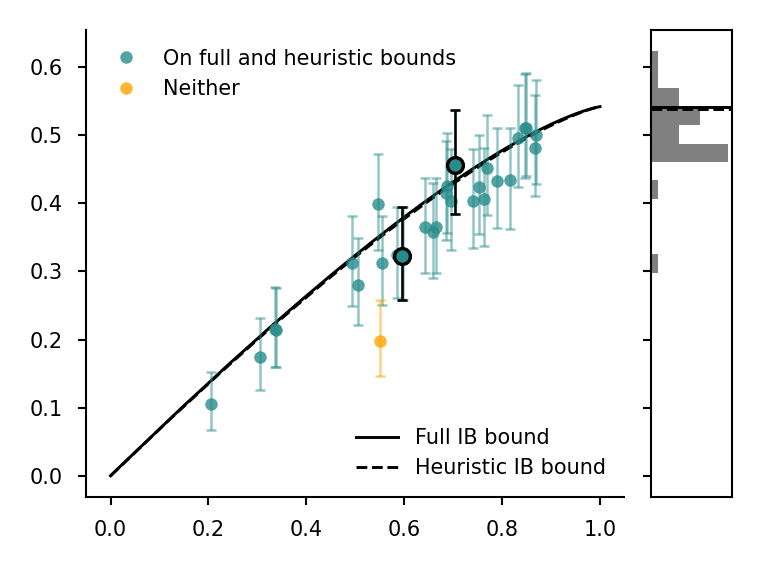

In [83]:
# plot subject data in IB space
# EXCLUDE those with I(X;R) < 0.05

highlighted_sjs = [26, 15]
exp = 'lowWS'
stats = 'lowWS'

alpha_dot = 0.8
alpha_line = 0.5

ibdf_ = ibdf_dict[exp].copy()

conds = (ibdf_['exclude_Ixr'] == 0)

fig, ax = plt.subplots(figsize=(2.7, 2), dpi=300)

full_bound, = ax.plot(bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'], 'k', linewidth=0.7, label='Full IB bound')
heur_bound, = ax.plot(bound_dict_horses[stats]['equal-weights']['I_XR'], bound_dict_horses[stats]['equal-weights']['I_RY'], '--k', linewidth=0.7, label='Heuristic IB bound')

for sjind in pd.unique(ibdf_[conds]['subject_index']):
    sjconds = conds & (ibdf_['subject_index'] == sjind)
    if ibdf_[sjconds]['bound_class'].to_numpy() == 'full' or ibdf_[sjconds]['bound_class'].to_numpy() == 'equal-weights':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        onfullbound, = ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=optcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On full and heuristic bounds')
    # elif ibdf_[sjconds]['bound_class'].to_numpy() == 'equal-weights':
    #     ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
    #     onheurbound, = ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=heurcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On heuristic bound')
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'none':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=nonecolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        other, = ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=nonecolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='Neither')

high_color = 'black'
high_width = 0.8
high_alpha = 1.0
for sjind in highlighted_sjs:
    sjconds = conds & (ibdf_[conds]['subject_index'] == sjind)
    if ibdf_[sjconds]['bound_class'].to_numpy() == 'full' or ibdf_[sjconds]['bound_class'].to_numpy() == 'equal-weights':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=optcolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)
    # elif ibdf_[sjconds]['bound_class'].to_numpy() == 'equal-weights':
    #     ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
    #     ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=heurcolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'none':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=nonecolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)

leg1 = ax.legend(handles=[onfullbound, other],fontsize=5, frameon=False, loc='upper left')
leg2 = ax.legend(handles=[full_bound, heur_bound],fontsize=5, frameon=False, loc='lower right')
ax.add_artist(leg1)

format_axis(ax)

# Iry_interp_opt = np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'])
Iry_interp_opt = np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'])
Iry_interp_heur = np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['equal-weights']['I_XR'], bound_dict_horses[stats]['equal-weights']['I_RY'])
heur_efficiency = Iry_interp_heur / np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'])

avg_rel_heur = heur_efficiency.mean()
yvals_norm = ibdf_.loc[conds,'info_efficiency'].to_numpy() * bound_dict_horses[stats]['full']['I_RY'].max()
bins = (np.arange(0,1.2,0.05)) * bound_dict_horses[stats]['full']['I_RY'].max()
counts, bins = np.histogram(yvals_norm, bins=bins)

ax_hist = ax.inset_axes([1.05, 0, 0.15, 1], sharey=ax)
ax_hist.barh((bins[:-1] + bins[1:]) / 2, counts, height=(bins[1] - bins[0]), color='gray')
ax_hist.axhline(bound_dict_horses[stats]['full']['I_RY'].max(), color='black', linestyle='-', linewidth=0.7)
ax_hist.axhline(avg_rel_heur * bound_dict_horses[stats]['full']['I_RY'].max(), color='black', linestyle='--', linewidth=0.7)
# ax_hist.set_xlabel('Count')
ax_hist.set_ylabel('')
# ax_hist.set_yticks([])
ax_hist.tick_params(axis='y', labelleft=False, labelsize=5, width=0.5, length=2)
ax_hist.set_xticks([])
ax_hist.set_ylim(ax.get_ylim())
ax_hist.grid(False)
ax_hist.spines['bottom'].set_linewidth(0.5)
ax_hist.spines['left'].set_linewidth(0.5)
ax_hist.spines['top'].set_linewidth(0.5)
ax_hist.spines['right'].set_linewidth(0.5)
plt.tight_layout()
savefig(fig, 'Figure5/figure5_horses_lowWS_IBplot')

In [27]:
ibdf_[conds]['bound_class'].value_counts()

equal-weights    23
full              6
none              1
Name: bound_class, dtype: int64

c:\Users\parja\Projects\human-inference-IB\utilities.py:865: RuntimeWarning: divide by zero encountered in log
  DKL = p_x * np.nansum(p_choice * np.log(p_choice / p_pred))
c:\Users\parja\Projects\human-inference-IB\utilities.py:865: RuntimeWarning: invalid value encountered in multiply
  DKL = p_x * np.nansum(p_choice * np.log(p_choice / p_pred))


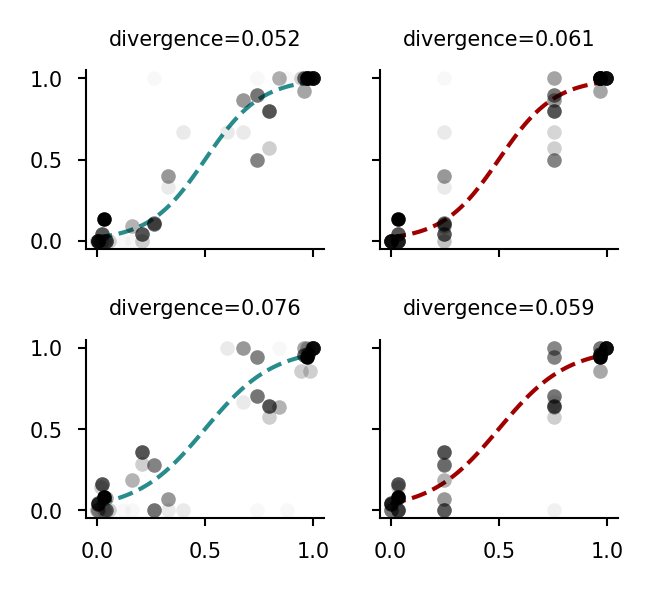

In [73]:
# psychometric functions for highlighted subjects, compared to IB-predicted psychometric functions for each bound (full and heuristic)

exp = 'lowWS'
stats = 'lowWS'

choicedf_ = pd.read_csv(horses_datadir + 'lowWS/sj-psychometric-data.csv')
postdf_ = pd.read_csv(horses_datadir + 'lowWS/strat-post-probs.csv')

ibdf_ = ibdf_dict[exp].copy()

fig, axs = plt.subplots(2,2, figsize=(2.3,2.05), dpi=300)

strats = ['fully-optimal','equal-weights']
strat_colors = {
    'fully-optimal': optcolor,
    'equal-weights': heurcolor
}
strat_bounds = {
    'fully-optimal': softmax_dict_horses[stats]['full'],
    'equal-weights': softmax_dict_horses[stats]['equal-weights']
}
conds1 = (choicedf_['subject_index'].notna())
conds2 = (ibdf_['subject_index'].notna())

for ii, sj in enumerate(highlighted_sjs):
    sjconds1 = conds1 & (choicedf_['subject_index'] == sj)
    sjconds2 = conds2 & (ibdf_['subject_index'] == sj)
    for jj, strat in enumerate(strats):
        utils.get_IB_predicted_psychometric_plot(ibdf_.loc[sjconds2,'Ixr'].values[0],strat_bounds[strat],strat_colors[strat],axs[ii,jj])
        utils.get_sj_psychometric_plot(choicedf_.loc[sjconds1], postdf_.loc[postdf_['strategy']==strat], axs[ii,jj])
        dkl = utils.get_psychometric_DKL(choicedf_.loc[sjconds1], postdf_.loc[postdf_['strategy']==strat],ibdf_.loc[sjconds2,'Ixr'].values[0],strat_bounds[strat])
        format_axis(axs[ii,jj])
        axs[ii,jj].set_title(f'divergence={dkl:.3f}', fontsize=5)
        if ii == 0:
            axs[ii,jj].set_xticklabels([])
        if jj == 1:
            axs[ii,jj].set_yticklabels([])
plt.tight_layout(pad=1)
savefig(fig, 'Figure5/figure5_horses_lowWS_PMFs')

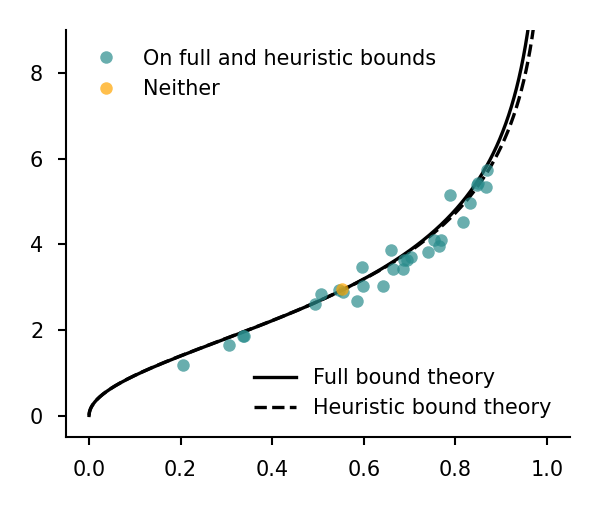

In [74]:
# plot choice noise term (best-fitting model betastar) vs I(X;R)
# EXCLUDE those with I(X;R) < 0.05

modeldf_ = pd.read_csv(horses_datadir + 'lowWS/model_fits.csv')
alldata_ = pd.merge(ibdf_, modeldf_, on=['subject_ID', 'subject_index'])

exp = 'lowWS'
stats = 'lowWS'
alldata_dict[exp] = alldata_.copy()

conds = (alldata_['exclude_Ixr'] == 0)

fig, ax = plt.subplots(figsize=(2.1, 1.8), dpi=300)

ib_theory, = ax.plot(softmax_dict_horses[stats]['full']['I_XR'], softmax_dict_horses[stats]['full']['betastar'], 'k', alpha=1,linewidth=0.8,label='Full bound theory')
heur_theory, = ax.plot(softmax_dict_horses[stats]['equal-weights']['I_XR'], softmax_dict_horses[stats]['equal-weights']['betastar'], '--k', alpha=1,linewidth=0.8,label='Heuristic bound theory')

for sjind in pd.unique(alldata_.loc[conds,'subject_index']):
    sjconds = conds & (alldata_['subject_index'] == sjind)
    if (alldata_.loc[conds & (alldata_['subject_index'] == sjind),'bound_class'].to_numpy() == 'full') or alldata_.loc[conds & (alldata_['subject_index'] == sjind),'bound_class'].to_numpy() == 'equal-weights':
        onfullbound, = ax.plot(alldata_.loc[sjconds,'Ixr'],alldata_.loc[sjconds,'best_model_betastar'],'o',c=optcolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On full and heuristic bounds')
    # elif alldata_.loc[conds & (alldata_['subject_index'] == sjind),'bound_class'].to_numpy() == 'equal-weights':
    #     onheurbound, = ax.plot(alldata_.loc[sjconds,'Ixr'],alldata_.loc[sjconds,'best_model_betastar'],'o',c=heurcolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On heuristic bound')
    elif alldata_.loc[conds & (alldata_['subject_index'] == sjind),'bound_class'].to_numpy() == 'none':
        other, = ax.plot(alldata_.loc[sjconds,'Ixr'],alldata_.loc[sjconds,'best_model_betastar'],'o',c=nonecolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='Neither')
leg1 = ax.legend(handles=[onfullbound, other],fontsize=5, frameon=False, loc='upper left')
leg2 = ax.legend(handles=[ib_theory, heur_theory],fontsize=5, frameon=False, loc='lower right')
ax.add_artist(leg1)
ax.set_ylim(-0.5,9)
format_axis(ax)
plt.tight_layout()
savefig(fig, 'Figure5/figure5_horses_lowWS_betastar_vs_Ixr')

### Intermediate WS-ratio experiment

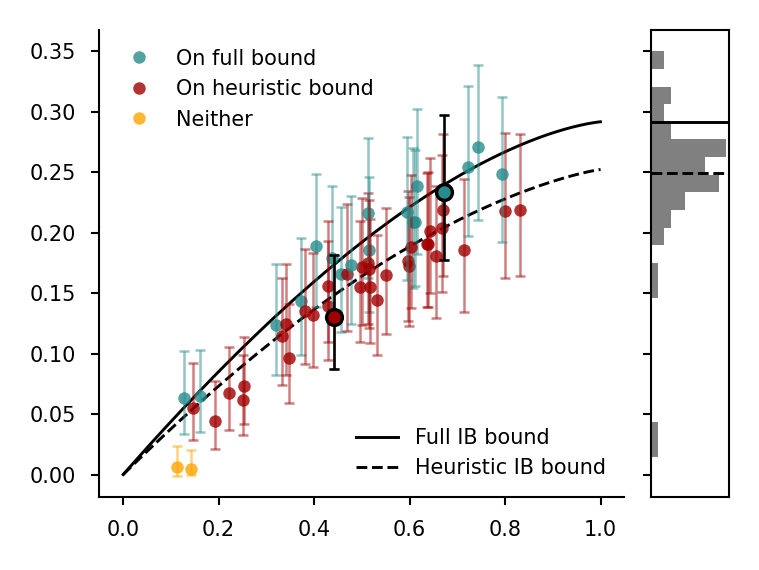

In [85]:
# plot subject data in IB space
# EXCLUDE those with I(X;R) < 0.05

highlighted_sjs = [10, 42]
exp = 'midWS'
stats = 'midWS'

alpha_dot = 0.8
alpha_line = 0.5

ibdf_ = ibdf_dict[exp].copy()

conds = (ibdf_['exclude_Ixr'] == 0)

fig, ax = plt.subplots(figsize=(2.7, 2), dpi=300)

full_bound, = ax.plot(bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'], 'k', linewidth=0.7, label='Full IB bound')
heur_bound, = ax.plot(bound_dict_horses[stats]['equal-weights']['I_XR'], bound_dict_horses[stats]['equal-weights']['I_RY'], '--k', linewidth=0.7, label='Heuristic IB bound')

for sjind in pd.unique(ibdf_[conds]['subject_index']):
    sjconds = conds & (ibdf_['subject_index'] == sjind)
    if ibdf_[sjconds]['bound_class'].to_numpy() == 'full':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        onfullbound, = ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=optcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On full bound')
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'equal-weights':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        onheurbound, = ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=heurcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On heuristic bound')
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'none':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=nonecolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        other, = ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=nonecolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='Neither')

high_color = 'black'
high_width = 0.8
high_alpha = 1.0
for sjind in highlighted_sjs:
    sjconds = conds & (ibdf_[conds]['subject_index'] == sjind)
    if ibdf_[sjconds]['bound_class'].to_numpy() == 'full':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=optcolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'equal-weights':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=heurcolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'none':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=nonecolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)

leg1 = ax.legend(handles=[onfullbound, onheurbound, other],fontsize=5, frameon=False, loc='upper left')
leg2 = ax.legend(handles=[full_bound, heur_bound],fontsize=5, frameon=False, loc='lower right')
ax.add_artist(leg1)

format_axis(ax)

# Iry_interp_opt = np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'])
Iry_interp_opt = np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'])
Iry_interp_heur = np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['equal-weights']['I_XR'], bound_dict_horses[stats]['equal-weights']['I_RY'])
heur_efficiency = Iry_interp_heur / np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'])

avg_rel_heur = heur_efficiency.mean()
yvals_norm = ibdf_.loc[conds,'info_efficiency'].to_numpy() * bound_dict_horses[stats]['full']['I_RY'].max()
bins = (np.arange(0,1.25,0.05)) * bound_dict_horses[stats]['full']['I_RY'].max()
counts, bins = np.histogram(yvals_norm, bins=bins)

ax_hist = ax.inset_axes([1.05, 0, 0.15, 1], sharey=ax)
ax_hist.barh((bins[:-1] + bins[1:]) / 2, counts, height=(bins[1] - bins[0]), color='gray')
ax_hist.axhline(bound_dict_horses[stats]['full']['I_RY'].max(), color='black', linestyle='-', linewidth=0.7)
ax_hist.axhline(avg_rel_heur * bound_dict_horses[stats]['full']['I_RY'].max(), color='black', linestyle='--', linewidth=0.7)
# ax_hist.set_xlabel('Count')
ax_hist.set_ylabel('')
# ax_hist.set_yticks([])
ax_hist.tick_params(axis='y', labelleft=False, labelsize=5, width=0.5, length=2)
ax_hist.set_xticks([])
ax_hist.set_ylim(ax.get_ylim())
ax_hist.grid(False)
ax_hist.spines['bottom'].set_linewidth(0.5)
ax_hist.spines['left'].set_linewidth(0.5)
ax_hist.spines['top'].set_linewidth(0.5)
ax_hist.spines['right'].set_linewidth(0.5)
plt.tight_layout()
savefig(fig, 'Figure5/figure5_horses_midWS_IBplot')

In [86]:
ibdf_[conds]['bound_class'].value_counts()

equal-weights    33
full             18
none              2
Name: bound_class, dtype: int64

c:\Users\parja\Projects\human-inference-IB\utilities.py:865: RuntimeWarning: divide by zero encountered in log
  DKL = p_x * np.nansum(p_choice * np.log(p_choice / p_pred))
c:\Users\parja\Projects\human-inference-IB\utilities.py:865: RuntimeWarning: invalid value encountered in multiply
  DKL = p_x * np.nansum(p_choice * np.log(p_choice / p_pred))


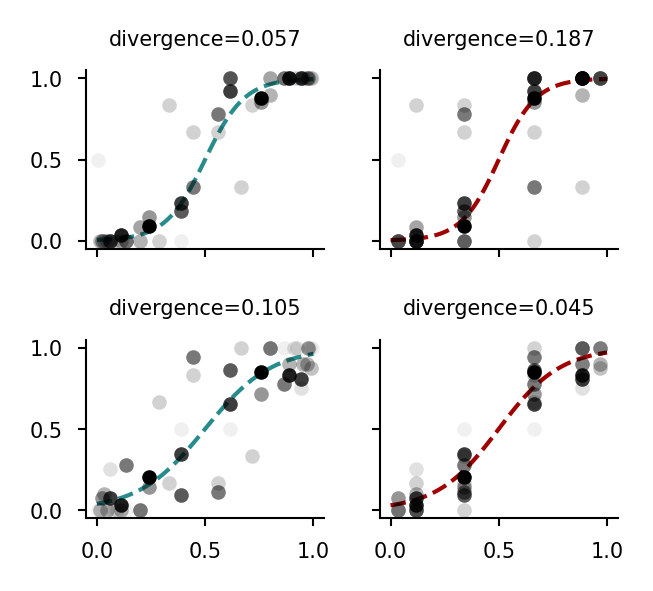

In [88]:
# psychometric functions for highlighted subjects, compared to IB-predicted psychometric functions for each bound (full and heuristic)

exp = 'midWS'
stats = 'midWS'

choicedf_ = pd.read_csv(horses_datadir + 'midWS_learning/midWS_sj-psychometric-data.csv')
postdf_ = pd.read_csv(horses_datadir + 'midWS_learning/strat-post-probs.csv')

ibdf_ = ibdf_dict[exp].copy()

fig, axs = plt.subplots(2,2, figsize=(2.3,2.05), dpi=300)

strats = ['fully-optimal','equal-weights']
strat_colors = {
    'fully-optimal': optcolor,
    'equal-weights': heurcolor
}
strat_bounds = {
    'fully-optimal': softmax_dict_horses[stats]['full'],
    'equal-weights': softmax_dict_horses[stats]['equal-weights']
}
conds1 = (choicedf_['subject_index'].notna())
conds2 = (ibdf_['subject_index'].notna())

for ii, sj in enumerate(highlighted_sjs):
    sjconds1 = conds1 & (choicedf_['subject_index'] == sj)
    sjconds2 = conds2 & (ibdf_['subject_index'] == sj)
    for jj, strat in enumerate(strats):
        utils.get_IB_predicted_psychometric_plot(ibdf_.loc[sjconds2,'Ixr'].values[0],strat_bounds[strat],strat_colors[strat],axs[ii,jj])
        utils.get_sj_psychometric_plot(choicedf_.loc[sjconds1], postdf_.loc[postdf_['strategy']==strat], axs[ii,jj])
        dkl = utils.get_psychometric_DKL(choicedf_.loc[sjconds1], postdf_.loc[postdf_['strategy']==strat],ibdf_.loc[sjconds2,'Ixr'].values[0],strat_bounds[strat])
        format_axis(axs[ii,jj])
        axs[ii,jj].set_title(f'divergence={dkl:.3f}', fontsize=5)
        if ii == 0:
            axs[ii,jj].set_xticklabels([])
        if jj == 1:
            axs[ii,jj].set_yticklabels([])
plt.tight_layout(pad=1)
savefig(fig, 'Figure5/figure5_horses_midWS_PMFs')

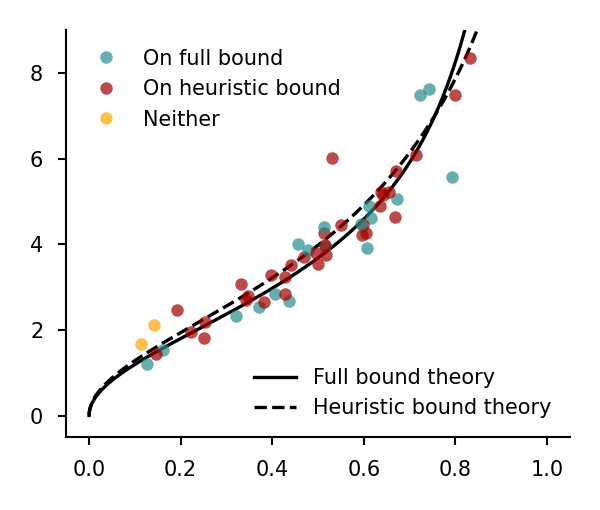

In [78]:
# plot choice noise term (best-fitting model betastar) vs I(X;R)
# EXCLUDE those with I(X;R) < 0.05

modeldf_ = pd.read_csv(horses_datadir + 'midWS_learning/midWS_model_fits.csv')
alldata_ = pd.merge(ibdf_, modeldf_, on=['subject_ID', 'subject_index'])

exp = 'midWS'
stats = 'midWS'
alldata_dict[exp] = alldata_.copy()

conds = (alldata_['exclude_Ixr'] == 0)

fig, ax = plt.subplots(figsize=(2.1, 1.8), dpi=300)

ib_theory, = ax.plot(softmax_dict_horses[stats]['full']['I_XR'], softmax_dict_horses[stats]['full']['betastar'], 'k', alpha=1,linewidth=0.8,label='Full bound theory')
heur_theory, = ax.plot(softmax_dict_horses[stats]['equal-weights']['I_XR'], softmax_dict_horses[stats]['equal-weights']['betastar'], '--k', alpha=1,linewidth=0.8,label='Heuristic bound theory')

for sjind in pd.unique(alldata_.loc[conds,'subject_index']):
    sjconds = conds & (alldata_['subject_index'] == sjind)
    if (alldata_.loc[conds & (alldata_['subject_index'] == sjind),'bound_class'].to_numpy() == 'full'):
        onfullbound, = ax.plot(alldata_.loc[sjconds,'Ixr'],alldata_.loc[sjconds,'best_model_betastar'],'o',c=optcolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On full bound')
    elif alldata_.loc[conds & (alldata_['subject_index'] == sjind),'bound_class'].to_numpy() == 'equal-weights':
        onheurbound, = ax.plot(alldata_.loc[sjconds,'Ixr'],alldata_.loc[sjconds,'best_model_betastar'],'o',c=heurcolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On heuristic bound')
    elif alldata_.loc[conds & (alldata_['subject_index'] == sjind),'bound_class'].to_numpy() == 'none':
        other, = ax.plot(alldata_.loc[sjconds,'Ixr'],alldata_.loc[sjconds,'best_model_betastar'],'o',c=nonecolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='Neither')
leg1 = ax.legend(handles=[onfullbound, onheurbound, other],fontsize=5, frameon=False, loc='upper left')
leg2 = ax.legend(handles=[ib_theory, heur_theory],fontsize=5, frameon=False, loc='lower right')
ax.add_artist(leg1)
ax.set_ylim(-0.5,9)
format_axis(ax)
plt.tight_layout()
savefig(fig, 'Figure5/figure5_horses_midWS_betastar_vs_Ixr')

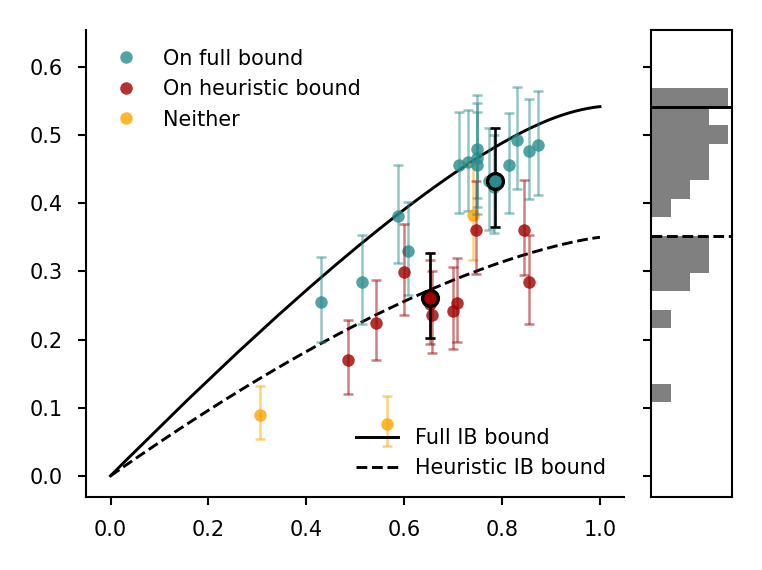

In [89]:
# plot subject data in IB space
# EXCLUDE those with I(X;R) < 0.05

highlighted_sjs = [55, 38]
exp = 'highWS'
stats = 'highWS'

alpha_dot = 0.8
alpha_line = 0.5

ibdf_ = ibdf_dict[exp].copy()

conds = (ibdf_['exclude_Ixr'] == 0)

fig, ax = plt.subplots(figsize=(2.7, 2), dpi=300)

full_bound, = ax.plot(bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'], 'k', linewidth=0.7, label='Full IB bound')
heur_bound, = ax.plot(bound_dict_horses[stats]['equal-weights']['I_XR'], bound_dict_horses[stats]['equal-weights']['I_RY'], '--k', linewidth=0.7, label='Heuristic IB bound')

for sjind in pd.unique(ibdf_[conds]['subject_index']):
    sjconds = conds & (ibdf_['subject_index'] == sjind)
    if ibdf_[sjconds]['bound_class'].to_numpy() == 'full':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        onfullbound, = ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=optcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On full bound')
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'equal-weights':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        onheurbound, = ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=heurcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On heuristic bound')
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'none':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=nonecolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        other, = ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=nonecolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='Neither')

high_color = 'black'
high_width = 0.8
high_alpha = 1.0
for sjind in highlighted_sjs:
    sjconds = conds & (ibdf_[conds]['subject_index'] == sjind)
    if ibdf_[sjconds]['bound_class'].to_numpy() == 'full':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=optcolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'equal-weights':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=heurcolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'none':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=nonecolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)

leg1 = ax.legend(handles=[onfullbound, onheurbound, other],fontsize=5, frameon=False, loc='upper left')
leg2 = ax.legend(handles=[full_bound, heur_bound],fontsize=5, frameon=False, loc='lower right')
ax.add_artist(leg1)

format_axis(ax)

# Iry_interp_opt = np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'])
Iry_interp_opt = np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'])
Iry_interp_heur = np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['equal-weights']['I_XR'], bound_dict_horses[stats]['equal-weights']['I_RY'])
heur_efficiency = Iry_interp_heur / np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'])

avg_rel_heur = heur_efficiency.mean()
yvals_norm = ibdf_.loc[conds,'info_efficiency'].to_numpy() * bound_dict_horses[stats]['full']['I_RY'].max()
bins = (np.arange(0,1.2,0.05)) * bound_dict_horses[stats]['full']['I_RY'].max()
counts, bins = np.histogram(yvals_norm, bins=bins)

ax_hist = ax.inset_axes([1.05, 0, 0.15, 1], sharey=ax)
ax_hist.barh((bins[:-1] + bins[1:]) / 2, counts, height=(bins[1] - bins[0]), color='gray')
ax_hist.axhline(bound_dict_horses[stats]['full']['I_RY'].max(), color='black', linestyle='-', linewidth=0.7)
ax_hist.axhline(avg_rel_heur * bound_dict_horses[stats]['full']['I_RY'].max(), color='black', linestyle='--', linewidth=0.7)
# ax_hist.set_xlabel('Count')
ax_hist.set_ylabel('')
# ax_hist.set_yticks([])
ax_hist.tick_params(axis='y', labelleft=False, labelsize=5, width=0.5, length=2)
ax_hist.set_xticks([])
ax_hist.set_ylim(ax.get_ylim())
ax_hist.grid(False)
ax_hist.spines['bottom'].set_linewidth(0.5)
ax_hist.spines['left'].set_linewidth(0.5)
ax_hist.spines['top'].set_linewidth(0.5)
ax_hist.spines['right'].set_linewidth(0.5)
plt.tight_layout()
savefig(fig, 'Figure5/figure5_horses_highWS_IBplot')

In [90]:
ibdf_[conds]['bound_class'].value_counts()

full             16
equal-weights    11
none              3
Name: bound_class, dtype: int64

c:\Users\parja\Projects\human-inference-IB\utilities.py:865: RuntimeWarning: divide by zero encountered in log
  DKL = p_x * np.nansum(p_choice * np.log(p_choice / p_pred))
c:\Users\parja\Projects\human-inference-IB\utilities.py:865: RuntimeWarning: invalid value encountered in multiply
  DKL = p_x * np.nansum(p_choice * np.log(p_choice / p_pred))


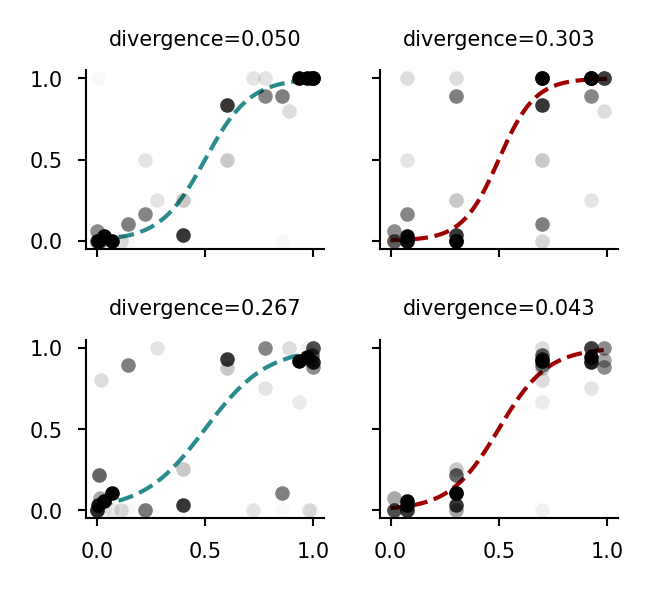

In [91]:
# psychometric functions for highlighted subjects, compared to IB-predicted psychometric functions for each bound (full and heuristic)

exp = 'highWS'
stats = 'highWS'

choicedf_ = pd.read_csv(horses_datadir + 'highWS/sj-psychometric-data.csv')
postdf_ = pd.read_csv(horses_datadir + 'highWS/strat-post-probs.csv')

ibdf_ = ibdf_dict[exp].copy()

fig, axs = plt.subplots(2,2, figsize=(2.3,2.05), dpi=300)

strats = ['fully-optimal','equal-weights']
strat_colors = {
    'fully-optimal': optcolor,
    'equal-weights': heurcolor
}
strat_bounds = {
    'fully-optimal': softmax_dict_horses[stats]['full'],
    'equal-weights': softmax_dict_horses[stats]['equal-weights']
}
conds1 = (choicedf_['subject_index'].notna())
conds2 = (ibdf_['subject_index'].notna())

for ii, sj in enumerate(highlighted_sjs):
    sjconds1 = conds1 & (choicedf_['subject_index'] == sj)
    sjconds2 = conds2 & (ibdf_['subject_index'] == sj)
    for jj, strat in enumerate(strats):
        utils.get_IB_predicted_psychometric_plot(ibdf_.loc[sjconds2,'Ixr'].values[0],strat_bounds[strat],strat_colors[strat],axs[ii,jj])
        utils.get_sj_psychometric_plot(choicedf_.loc[sjconds1], postdf_.loc[postdf_['strategy']==strat], axs[ii,jj])
        dkl = utils.get_psychometric_DKL(choicedf_.loc[sjconds1], postdf_.loc[postdf_['strategy']==strat],ibdf_.loc[sjconds2,'Ixr'].values[0],strat_bounds[strat])
        format_axis(axs[ii,jj])
        axs[ii,jj].set_title(f'divergence={dkl:.3f}', fontsize=5)
        if ii == 0:
            axs[ii,jj].set_xticklabels([])
        if jj == 1:
            axs[ii,jj].set_yticklabels([])
plt.tight_layout(pad=1)
savefig(fig, 'Figure5/figure5_horses_highWS_PMFs')

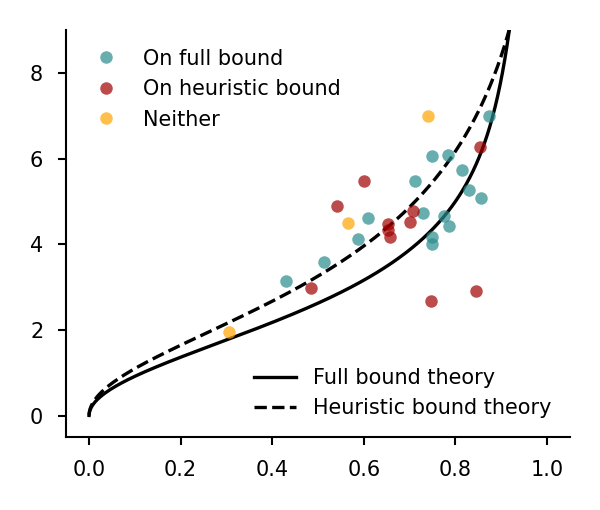

In [92]:
# plot choice noise term (best-fitting model betastar) vs I(X;R)
# EXCLUDE those with I(X;R) < 0.05

modeldf_ = pd.read_csv(horses_datadir + 'highWS/model_fits.csv')
alldata_ = pd.merge(ibdf_, modeldf_, on=['subject_ID', 'subject_index'])

exp = 'highWS'
stats = 'highWS'
alldata_dict[exp] = alldata_.copy()

conds = (alldata_['exclude_Ixr'] == 0)

fig, ax = plt.subplots(figsize=(2.1, 1.8), dpi=300)

ib_theory, = ax.plot(softmax_dict_horses[stats]['full']['I_XR'], softmax_dict_horses[stats]['full']['betastar'], 'k', alpha=1,linewidth=0.8,label='Full bound theory')
heur_theory, = ax.plot(softmax_dict_horses[stats]['equal-weights']['I_XR'], softmax_dict_horses[stats]['equal-weights']['betastar'], '--k', alpha=1,linewidth=0.8,label='Heuristic bound theory')

for sjind in pd.unique(alldata_.loc[conds,'subject_index']):
    sjconds = conds & (alldata_['subject_index'] == sjind)
    if (alldata_.loc[conds & (alldata_['subject_index'] == sjind),'bound_class'].to_numpy() == 'full'):
        onfullbound, = ax.plot(alldata_.loc[sjconds,'Ixr'],alldata_.loc[sjconds,'best_model_betastar'],'o',c=optcolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On full bound')
    elif alldata_.loc[conds & (alldata_['subject_index'] == sjind),'bound_class'].to_numpy() == 'equal-weights':
        onheurbound, = ax.plot(alldata_.loc[sjconds,'Ixr'],alldata_.loc[sjconds,'best_model_betastar'],'o',c=heurcolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On heuristic bound')
    elif alldata_.loc[conds & (alldata_['subject_index'] == sjind),'bound_class'].to_numpy() == 'none':
        other, = ax.plot(alldata_.loc[sjconds,'Ixr'],alldata_.loc[sjconds,'best_model_betastar'],'o',c=nonecolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='Neither')
leg1 = ax.legend(handles=[onfullbound, onheurbound, other],fontsize=5, frameon=False, loc='upper left')
leg2 = ax.legend(handles=[ib_theory, heur_theory],fontsize=5, frameon=False, loc='lower right')
ax.add_artist(leg1)
ax.set_ylim(-0.5,9)
format_axis(ax)
plt.tight_layout()
savefig(fig, 'Figure5/figure5_horses_highWS_betastar_vs_Ixr')

## Figure 6
Model-fitting and comparision analyses for the horse-prediction experiments

### Low WS-ratio experiment

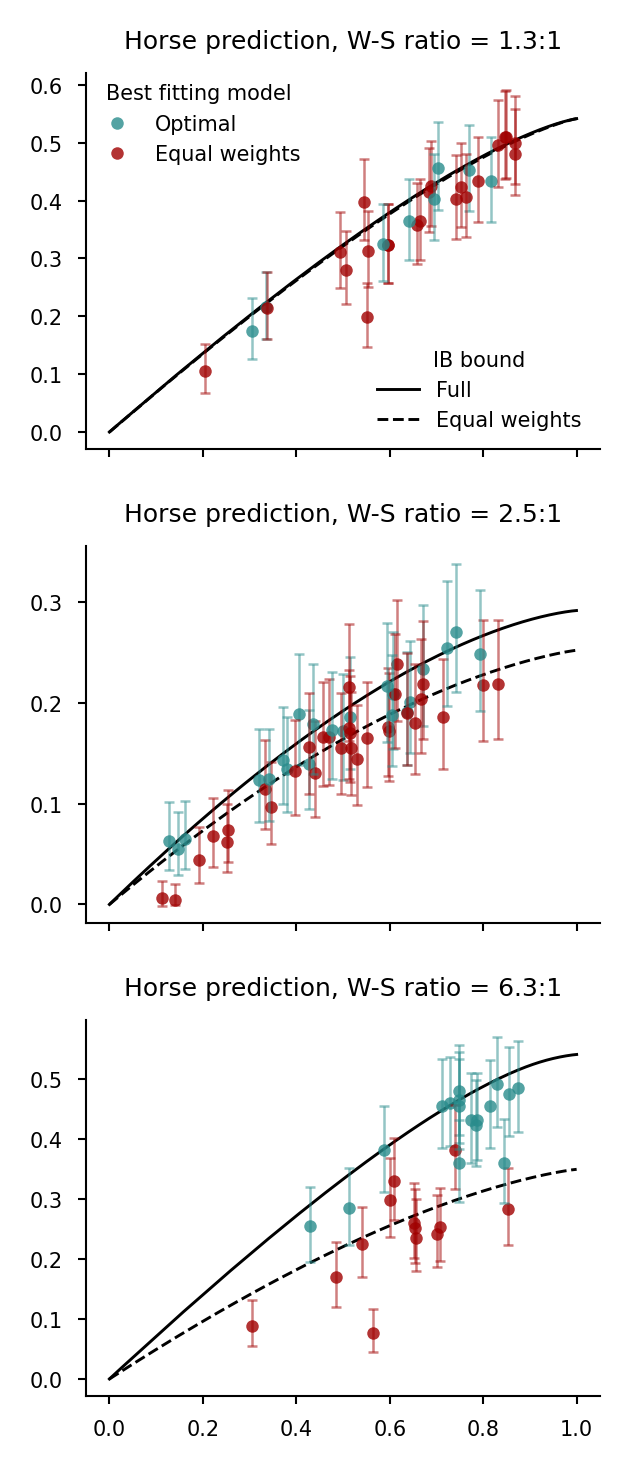

In [94]:


exp = 'lowWS'

alldata_ = alldata_dict[exp].copy()
conds = (alldata_['exclude_Ixr']==0)

fig, axs = plt.subplots(3, 1, figsize=(2.2, 5), dpi=300, sharex=True)

full_bound, = axs[0].plot(bound_dict_horses[exp]['full']['I_XR'], bound_dict_horses[exp]['full']['I_RY'], 'k', linewidth=0.7, label='Full')
heur_bound, = axs[0].plot(bound_dict_horses[exp]['equal-weights']['I_XR'], bound_dict_horses[exp]['equal-weights']['I_RY'], '--k', linewidth=0.7, label='Equal weights')

for sjind in pd.unique(alldata_[conds]['subject_index']):
    sjconds = conds & (alldata_['subject_index'] == sjind)
    if alldata_.loc[sjconds, 'opt_BIC'].iat[0] <= alldata_.loc[sjconds, 'equalweights_BIC'].iat[0]:
        axs[0].errorbar(alldata_[sjconds]['Ixr'], alldata_[sjconds]['Iry'], yerr=[alldata_[sjconds]['Iry'] - alldata_[sjconds]['Iry_CI_lower'], alldata_[sjconds]['Iry_CI_upper'] - alldata_[sjconds]['Iry']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        ibopt, = axs[0].plot(alldata_[sjconds]['Ixr'],alldata_[sjconds]['Iry'],'o',c=optcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='IB optimal')
    elif alldata_.loc[sjconds, 'opt_BIC'].iat[0] > alldata_.loc[sjconds, 'equalweights_BIC'].iat[0]:
        axs[0].errorbar(alldata_[sjconds]['Ixr'], alldata_[sjconds]['Iry'], yerr=[alldata_[sjconds]['Iry'] - alldata_[sjconds]['Iry_CI_lower'], alldata_[sjconds]['Iry_CI_upper'] - alldata_[sjconds]['Iry']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        ew, = axs[0].plot(alldata_[sjconds]['Ixr'],alldata_[sjconds]['Iry'],'o',c=heurcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='Equal weights heuristic')
format_axis(axs[0])
axs[0].set_title('Horse prediction, W-S ratio = 1.3:1', fontsize=6)
leg1 = axs[0].legend(handles=[full_bound, heur_bound], labels=['Full', 'Equal weights'], title='IB bound', loc='lower right', title_fontsize=5, fontsize=5, frameon=False)
leg2 = axs[0].legend(handles=[ibopt, ew], labels=['Optimal', 'Equal weights'], fontsize=5, frameon=False, title='Best fitting model',  title_fontsize=5, borderpad=0)
axs[0].add_artist(leg1)

# axs[0].legend(handles=[ibopt, ew], labels=['Optimal', 'Equal weights'], fontsize=5, frameon=False, title='Best fitting model',  title_fontsize=5, borderpad=0)

exp = 'midWS'

alldata_ = alldata_dict[exp].copy()
conds = (alldata_['exclude_Ixr']==0)

full_bound, = axs[1].plot(bound_dict_horses[exp]['full']['I_XR'], bound_dict_horses[exp]['full']['I_RY'], 'k', linewidth=0.7, label='Full')
heur_bound, = axs[1].plot(bound_dict_horses[exp]['equal-weights']['I_XR'], bound_dict_horses[exp]['equal-weights']['I_RY'], '--k', linewidth=0.7, label='Equal weights')

for sjind in pd.unique(alldata_[conds]['subject_index']):
    sjconds = conds & (alldata_['subject_index'] == sjind)
    if alldata_.loc[sjconds, 'opt_BIC'].iat[0] <= alldata_.loc[sjconds, 'equalweights_BIC'].iat[0]:
        axs[1].errorbar(alldata_[sjconds]['Ixr'], alldata_[sjconds]['Iry'], yerr=[alldata_[sjconds]['Iry'] - alldata_[sjconds]['Iry_CI_lower'], alldata_[sjconds]['Iry_CI_upper'] - alldata_[sjconds]['Iry']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        ibopt, = axs[1].plot(alldata_[sjconds]['Ixr'],alldata_[sjconds]['Iry'],'o',c=optcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='IB optimal')
    elif alldata_.loc[sjconds, 'opt_BIC'].iat[0] > alldata_.loc[sjconds, 'equalweights_BIC'].iat[0]:
        axs[1].errorbar(alldata_[sjconds]['Ixr'], alldata_[sjconds]['Iry'], yerr=[alldata_[sjconds]['Iry'] - alldata_[sjconds]['Iry_CI_lower'], alldata_[sjconds]['Iry_CI_upper'] - alldata_[sjconds]['Iry']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        ew, = axs[1].plot(alldata_[sjconds]['Ixr'],alldata_[sjconds]['Iry'],'o',c=heurcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='Equal weights heuristic')
format_axis(axs[1])
axs[1].set_title('Horse prediction, W-S ratio = 2.5:1', fontsize=6)
axs[1].set_yticks([0,0.1,0.2,0.3])


exp = 'highWS'

alldata_ = alldata_dict[exp].copy()
conds = (alldata_['exclude_Ixr']==0)

full_bound, = axs[2].plot(bound_dict_horses[exp]['full']['I_XR'], bound_dict_horses[exp]['full']['I_RY'], 'k', linewidth=0.7, label='Full')
heur_bound, = axs[2].plot(bound_dict_horses[exp]['equal-weights']['I_XR'], bound_dict_horses[exp]['equal-weights']['I_RY'], '--k', linewidth=0.7, label='Equal weights')

for sjind in pd.unique(alldata_[conds]['subject_index']):
    sjconds = conds & (alldata_['subject_index'] == sjind)
    if alldata_.loc[sjconds, 'opt_BIC'].iat[0] <= alldata_.loc[sjconds, 'equalweights_BIC'].iat[0]:
        axs[2].errorbar(alldata_[sjconds]['Ixr'], alldata_[sjconds]['Iry'], yerr=[alldata_[sjconds]['Iry'] - alldata_[sjconds]['Iry_CI_lower'], alldata_[sjconds]['Iry_CI_upper'] - alldata_[sjconds]['Iry']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        ibopt, = axs[2].plot(alldata_[sjconds]['Ixr'],alldata_[sjconds]['Iry'],'o',c=optcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='IB optimal')
    elif alldata_.loc[sjconds, 'opt_BIC'].iat[0] > alldata_.loc[sjconds, 'equalweights_BIC'].iat[0]:
        axs[2].errorbar(alldata_[sjconds]['Ixr'], alldata_[sjconds]['Iry'], yerr=[alldata_[sjconds]['Iry'] - alldata_[sjconds]['Iry_CI_lower'], alldata_[sjconds]['Iry_CI_upper'] - alldata_[sjconds]['Iry']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        ew, = axs[2].plot(alldata_[sjconds]['Ixr'],alldata_[sjconds]['Iry'],'o',c=heurcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='Equal weights heuristic')
format_axis(axs[2])
axs[2].set_title('Horse prediction, W-S ratio = 6.3:1', fontsize=6)

plt.tight_layout()
savefig(fig, 'Figure6/figure6_horses_two-model-comparison')

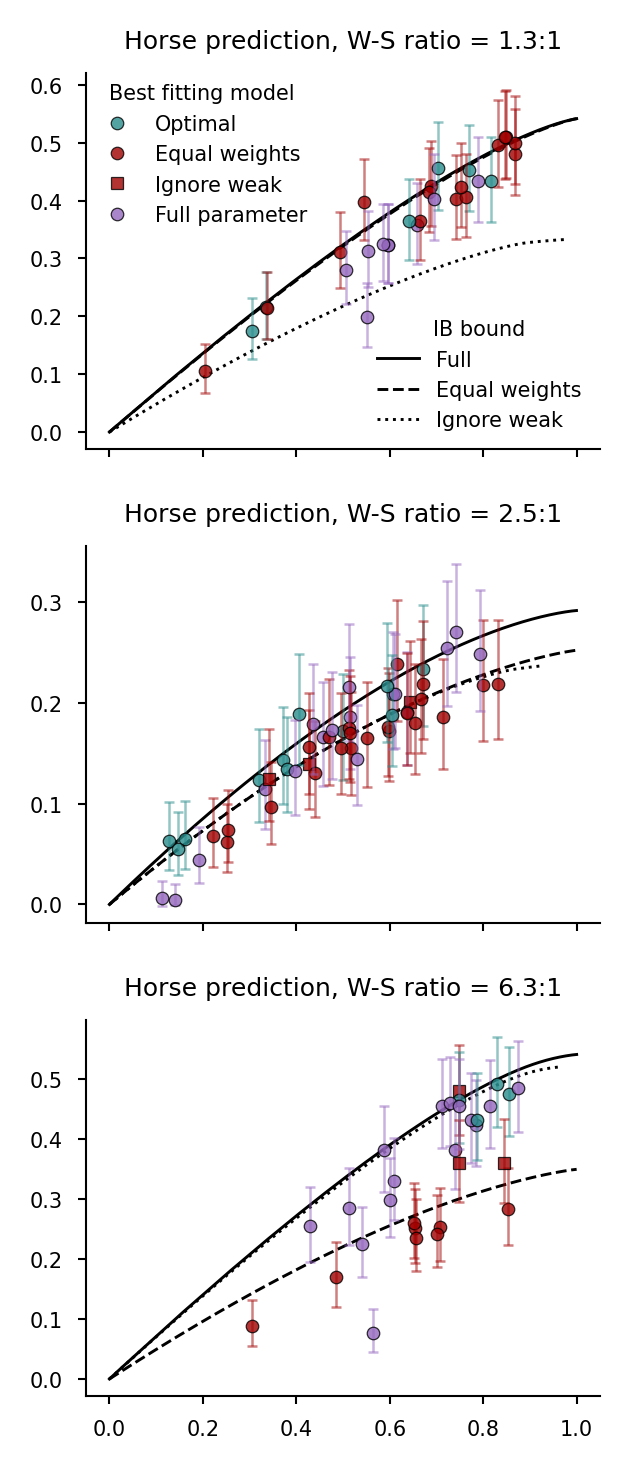

In [122]:

exp = 'lowWS'

alldata_ = alldata_dict[exp].copy()
conds = (alldata_['exclude_Ixr']==0)

mew = 0.3
mec = 'k'

fig, axs = plt.subplots(3, 1, figsize=(2.2, 5), dpi=300, sharex=True)

full_bound, = axs[0].plot(bound_dict_horses[exp]['full']['I_XR'], bound_dict_horses[exp]['full']['I_RY'], 'k', linewidth=0.7, label='Full')
ew_bound, = axs[0].plot(bound_dict_horses[exp]['equal-weights']['I_XR'], bound_dict_horses[exp]['equal-weights']['I_RY'], '--k', linewidth=0.7, label='Equal weights')
iw_bound, = axs[0].plot(bound_dict_horses[exp]['ignore-weak']['I_XR'], bound_dict_horses[exp]['ignore-weak']['I_RY'], ':k', linewidth=0.7, label='Ignore weak')

for sjind in pd.unique(alldata_[conds]['subject_index']):
    sjconds = conds & (alldata_['subject_index'] == sjind)
    if alldata_.loc[sjconds, 'best_model'].iat[0] == 'fully_optimal':
        axs[0].errorbar(alldata_[sjconds]['Ixr'], alldata_[sjconds]['Iry'], yerr=[alldata_[sjconds]['Iry'] - alldata_[sjconds]['Iry_CI_lower'], alldata_[sjconds]['Iry_CI_upper'] - alldata_[sjconds]['Iry']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        ibopt, = axs[0].plot(alldata_[sjconds]['Ixr'],alldata_[sjconds]['Iry'],'o',c=optcolor,alpha=alpha_dot,markersize=3,markeredgewidth=mew,markeredgecolor=mec,label='IB optimal')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'equalweights':
        axs[0].errorbar(alldata_[sjconds]['Ixr'], alldata_[sjconds]['Iry'], yerr=[alldata_[sjconds]['Iry'] - alldata_[sjconds]['Iry_CI_lower'], alldata_[sjconds]['Iry_CI_upper'] - alldata_[sjconds]['Iry']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        ew, = axs[0].plot(alldata_[sjconds]['Ixr'],alldata_[sjconds]['Iry'],'o',c=heurcolor,alpha=alpha_dot,markersize=3,markeredgewidth=mew,markeredgecolor=mec,label='Equal weights heuristic')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'ignoreweak':
        axs[0].errorbar(alldata_[sjconds]['Ixr'], alldata_[sjconds]['Iry'], yerr=[alldata_[sjconds]['Iry'] - alldata_[sjconds]['Iry_CI_lower'], alldata_[sjconds]['Iry_CI_upper'] - alldata_[sjconds]['Iry']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        iw, = axs[0].plot(alldata_[sjconds]['Ixr'],alldata_[sjconds]['Iry'],'s',c=heurcolor,alpha=alpha_dot,markersize=3,markeredgewidth=mew,markeredgecolor=mec,label='Ignore weak heuristic')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'fullparam':
        axs[0].errorbar(alldata_[sjconds]['Ixr'], alldata_[sjconds]['Iry'], yerr=[alldata_[sjconds]['Iry'] - alldata_[sjconds]['Iry_CI_lower'], alldata_[sjconds]['Iry_CI_upper'] - alldata_[sjconds]['Iry']], fmt='none', ecolor=fullparamcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        fp, = axs[0].plot(alldata_[sjconds]['Ixr'],alldata_[sjconds]['Iry'],'o',c=fullparamcolor,alpha=alpha_dot,markersize=3,markeredgewidth=mew,markeredgecolor=mec,label='Full parameter')
iw, = axs[0].plot([],[], 's', c=heurcolor, alpha=alpha_dot, markersize=3, markeredgewidth=mew, markeredgecolor=mec, label='Ignore weak heuristic')
format_axis(axs[0])
axs[0].set_title('Horse prediction, W-S ratio = 1.3:1', fontsize=6)
leg1 = axs[0].legend(handles=[full_bound, ew_bound, iw_bound], labels=['Full', 'Equal weights', 'Ignore weak'], title='IB bound', loc='lower right', title_fontsize=5, fontsize=5, frameon=False)
leg2 = axs[0].legend(handles=[ibopt, ew, iw, fp], labels=['Optimal', 'Equal weights', 'Ignore weak', 'Full parameter'], fontsize=5, frameon=False, title='Best fitting model',  title_fontsize=5, borderpad=0)
axs[0].add_artist(leg1)

# axs[0].legend(handles=[ibopt, ew], labels=['Optimal', 'Equal weights'], fontsize=5, frameon=False, title='Best fitting model',  title_fontsize=5, borderpad=0)

exp = 'midWS'

alldata_ = alldata_dict[exp].copy()
conds = (alldata_['exclude_Ixr']==0)

full_bound, = axs[1].plot(bound_dict_horses[exp]['full']['I_XR'], bound_dict_horses[exp]['full']['I_RY'], 'k', linewidth=0.7, label='Full')
ew_bound, = axs[1].plot(bound_dict_horses[exp]['equal-weights']['I_XR'], bound_dict_horses[exp]['equal-weights']['I_RY'], '--k', linewidth=0.7, label='Equal weights')
iw_bound, = axs[1].plot(bound_dict_horses[exp]['ignore-weak']['I_XR'], bound_dict_horses[exp]['ignore-weak']['I_RY'], ':k', linewidth=0.7, label='Ignore weak')
for sjind in pd.unique(alldata_[conds]['subject_index']):
    sjconds = conds & (alldata_['subject_index'] == sjind)
    if alldata_.loc[sjconds, 'best_model'].iat[0] == 'fully_optimal':
        axs[1].errorbar(alldata_[sjconds]['Ixr'], alldata_[sjconds]['Iry'], yerr=[alldata_[sjconds]['Iry'] - alldata_[sjconds]['Iry_CI_lower'], alldata_[sjconds]['Iry_CI_upper'] - alldata_[sjconds]['Iry']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        ibopt, = axs[1].plot(alldata_[sjconds]['Ixr'],alldata_[sjconds]['Iry'],'o',c=optcolor,alpha=alpha_dot,markersize=3,markeredgewidth=mew,markeredgecolor=mec,label='IB optimal')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'equalweights':
        axs[1].errorbar(alldata_[sjconds]['Ixr'], alldata_[sjconds]['Iry'], yerr=[alldata_[sjconds]['Iry'] - alldata_[sjconds]['Iry_CI_lower'], alldata_[sjconds]['Iry_CI_upper'] - alldata_[sjconds]['Iry']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        ew, = axs[1].plot(alldata_[sjconds]['Ixr'],alldata_[sjconds]['Iry'],'o',c=heurcolor,alpha=alpha_dot,markersize=3,markeredgewidth=mew,markeredgecolor=mec,label='Equal weights heuristic')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'ignoreweak':
        axs[1].errorbar(alldata_[sjconds]['Ixr'], alldata_[sjconds]['Iry'], yerr=[alldata_[sjconds]['Iry'] - alldata_[sjconds]['Iry_CI_lower'], alldata_[sjconds]['Iry_CI_upper'] - alldata_[sjconds]['Iry']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        iw, = axs[1].plot(alldata_[sjconds]['Ixr'],alldata_[sjconds]['Iry'],'s',c=heurcolor,alpha=alpha_dot,markersize=3,markeredgewidth=mew,markeredgecolor=mec,label='Ignore weak heuristic')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'fullparam':
        axs[1].errorbar(alldata_[sjconds]['Ixr'], alldata_[sjconds]['Iry'], yerr=[alldata_[sjconds]['Iry'] - alldata_[sjconds]['Iry_CI_lower'], alldata_[sjconds]['Iry_CI_upper'] - alldata_[sjconds]['Iry']], fmt='none', ecolor=fullparamcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        fp, = axs[1].plot(alldata_[sjconds]['Ixr'],alldata_[sjconds]['Iry'],'o',c=fullparamcolor,alpha=alpha_dot,markersize=3,markeredgewidth=mew,markeredgecolor=mec,label='Full parameter')
format_axis(axs[1])
axs[1].set_title('Horse prediction, W-S ratio = 2.5:1', fontsize=6)
axs[1].set_yticks([0,0.1,0.2,0.3])


exp = 'highWS'

alldata_ = alldata_dict[exp].copy()
conds = (alldata_['exclude_Ixr']==0)

full_bound, = axs[2].plot(bound_dict_horses[exp]['full']['I_XR'], bound_dict_horses[exp]['full']['I_RY'], 'k', linewidth=0.7, label='Full')
ew_bound, = axs[2].plot(bound_dict_horses[exp]['equal-weights']['I_XR'], bound_dict_horses[exp]['equal-weights']['I_RY'], '--k', linewidth=0.7, label='Equal weights')
iw_bound, = axs[2].plot(bound_dict_horses[exp]['ignore-weak']['I_XR'], bound_dict_horses[exp]['ignore-weak']['I_RY'], ':k', linewidth=0.7, label='Ignore weak')

for sjind in pd.unique(alldata_[conds]['subject_index']):
    sjconds = conds & (alldata_['subject_index'] == sjind)
    if alldata_.loc[sjconds, 'best_model'].iat[0] == 'fully_optimal':
        axs[2].errorbar(alldata_[sjconds]['Ixr'], alldata_[sjconds]['Iry'], yerr=[alldata_[sjconds]['Iry'] - alldata_[sjconds]['Iry_CI_lower'], alldata_[sjconds]['Iry_CI_upper'] - alldata_[sjconds]['Iry']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        ibopt, = axs[2].plot(alldata_[sjconds]['Ixr'],alldata_[sjconds]['Iry'],'o',c=optcolor,alpha=alpha_dot,markersize=3,markeredgewidth=mew,markeredgecolor=mec,label='IB optimal')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'equalweights':
        axs[2].errorbar(alldata_[sjconds]['Ixr'], alldata_[sjconds]['Iry'], yerr=[alldata_[sjconds]['Iry'] - alldata_[sjconds]['Iry_CI_lower'], alldata_[sjconds]['Iry_CI_upper'] - alldata_[sjconds]['Iry']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        ew, = axs[2].plot(alldata_[sjconds]['Ixr'],alldata_[sjconds]['Iry'],'o',c=heurcolor,alpha=alpha_dot,markersize=3,markeredgewidth=mew,markeredgecolor=mec,label='Equal weights heuristic')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'ignoreweak':
        axs[2].errorbar(alldata_[sjconds]['Ixr'], alldata_[sjconds]['Iry'], yerr=[alldata_[sjconds]['Iry'] - alldata_[sjconds]['Iry_CI_lower'], alldata_[sjconds]['Iry_CI_upper'] - alldata_[sjconds]['Iry']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        iw, = axs[2].plot(alldata_[sjconds]['Ixr'],alldata_[sjconds]['Iry'],'s',c=heurcolor,alpha=alpha_dot,markersize=3,markeredgewidth=mew,markeredgecolor=mec,label='Ignore weak heuristic')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'fullparam':
        axs[2].errorbar(alldata_[sjconds]['Ixr'], alldata_[sjconds]['Iry'], yerr=[alldata_[sjconds]['Iry'] - alldata_[sjconds]['Iry_CI_lower'], alldata_[sjconds]['Iry_CI_upper'] - alldata_[sjconds]['Iry']], fmt='none', ecolor=fullparamcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        fp, = axs[2].plot(alldata_[sjconds]['Ixr'],alldata_[sjconds]['Iry'],'o',c=fullparamcolor,alpha=alpha_dot,markersize=3,markeredgewidth=mew,markeredgecolor=mec,label='Full parameter')
format_axis(axs[2])
axs[2].set_title('Horse prediction, W-S ratio = 6.3:1', fontsize=6)

plt.tight_layout()
savefig(fig, 'Figure6/figure6_horses_all-model-comparison')

In [123]:
# best model counts for lowWS condition
conds = (alldata_dict['lowWS']['exclude_Ixr']==0)
alldata_dict['lowWS'].loc[conds, 'best_model'].value_counts()

equalweights     15
fullparam         9
fully_optimal     6
Name: best_model, dtype: int64

In [124]:
# best model counts by bound class, for lowWS condition
conds = (alldata_dict['lowWS']['exclude_Ixr']==0)
alldata_dict['lowWS'].loc[conds].groupby('bound_class')['best_model'].value_counts()

bound_class    best_model   
equal-weights  equalweights     10
               fullparam         8
               fully_optimal     5
full           equalweights      5
               fully_optimal     1
none           fullparam         1
Name: best_model, dtype: int64

In [125]:
# best model counts for midWS condition
conds = (alldata_dict['midWS']['exclude_Ixr']==0)
alldata_dict['midWS'].loc[conds, 'best_model'].value_counts()

equalweights     22
fullparam        17
fully_optimal    11
ignoreweak        3
Name: best_model, dtype: int64

In [126]:
# best model counts by bound class, for midWS condition
conds = (alldata_dict['midWS']['exclude_Ixr']==0)
alldata_dict['midWS'].loc[conds].groupby('bound_class')['best_model'].value_counts()

bound_class    best_model   
equal-weights  equalweights     21
               fullparam         5
               fully_optimal     4
               ignoreweak        3
full           fullparam        10
               fully_optimal     7
               equalweights      1
none           fullparam         2
Name: best_model, dtype: int64

In [127]:
# best model counts for highWS condition
conds = (alldata_dict['highWS']['exclude_Ixr']==0)
alldata_dict['highWS'].loc[conds, 'best_model'].value_counts()

fullparam        15
equalweights      8
fully_optimal     4
ignoreweak        3
Name: best_model, dtype: int64

In [128]:
# best model counts by bound class, for highWS condition
conds = (alldata_dict['highWS']['exclude_Ixr']==0)
alldata_dict['highWS'].loc[conds].groupby('bound_class')['best_model'].value_counts()

bound_class    best_model   
equal-weights  equalweights      7
               fullparam         2
               ignoreweak        2
full           fullparam        11
               fully_optimal     4
               ignoreweak        1
none           fullparam         2
               equalweights      1
Name: best_model, dtype: int64

In [98]:
if loaddataflag and os.path.exists(horses_datadir + 'WSratio_efficiencies.pkl'):
    with open(horses_datadir + 'WSratio_efficiencies.pkl', 'rb') as f:
        dat = pickle.load(f)
    infoeff_dict_horses = dat['infoeff_dict_horses']
    WSratio_vals = np.arange(0,10.1,0.1)
else:
    WSratio_vals = np.arange(0,10.1,0.1)
    betastar_vals = np.linspace(max_b_softmax/N_b_softmax,max_b_softmax,N_b_softmax)

    infoeff_dict_horses = {}
    for exp in ['lowWS', 'midWS', 'highWS']:

        def fullparam_model_horses(WSratio, betastar):
            p_YgX_fullparam = utils.P_horse_g_shapecomb(shapes_emp_dict[exp]['full'],paramdict[exp]['weakLLR'],WSratio,paramdict[exp]['p1'],p_Y)
            return softmax(betastar*p_YgX_fullparam, axis=1)
        
        conds = (alldata_dict[exp]['exclude_Ixr']==0)
        Ixr_vals = alldata_dict[exp].loc[conds,'Ixr'].to_numpy()
        infoeff_dict_horses[exp] = utils.get_efficiency_vs_parameter_curve(WSratio_vals, betastar_vals, fullparam_model_horses, shapes_emp_dict[exp]['full'], horses_emp_dict[exp], Ixr_vals, bound_dict_horses[exp]['full'])
    if savedataflag:
        with open(horses_datadir + 'WSratio_efficiencies.pkl', 'wb') as f:
            pickle.dump({
                'infoeff_dict_horses': infoeff_dict_horses
            }, f)

C:\Users\parja\AppData\Local\Temp\ipykernel_42288\908420343.py:244: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


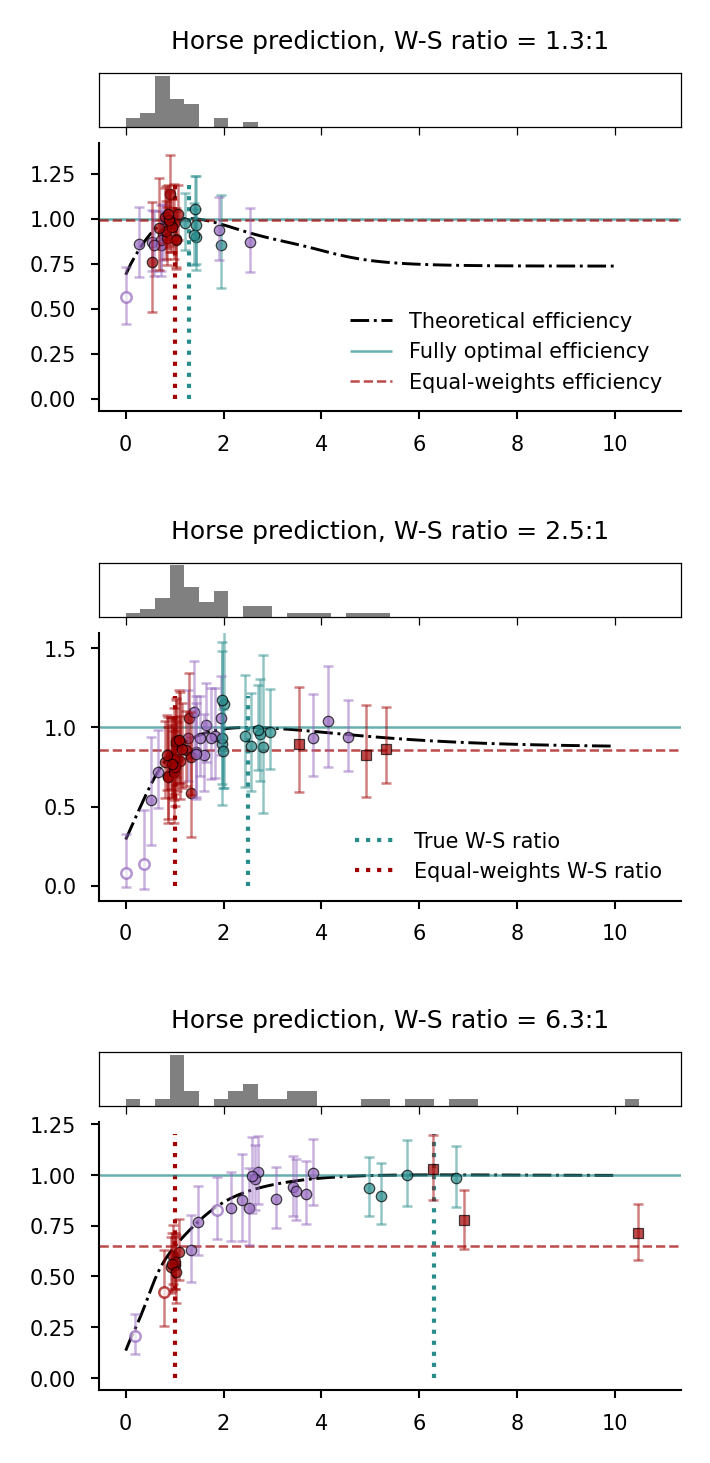

In [99]:
import matplotlib.gridspec as gridspec

alpha_dot = 0.8
alpha_line = 0.5
lsiw = '-.'
msiw = 's'
mec = 'black'
mew = 0.3
ms = 2.5

xlim = (-0.54, 11.34)

bins = np.arange(0,11,0.3)

fig = plt.figure(figsize=(2.5, 5.7), dpi=300)

gs_main = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45)

gs_ew = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_main[0], height_ratios=[1, 5], hspace=0.1)
gs_base = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_main[1], height_ratios=[1, 5], hspace=0.1)
gs_iw = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_main[2], height_ratios=[1, 5], hspace=0.1)

axs = []
axs.append(fig.add_subplot(gs_ew[0]))
axs.append(fig.add_subplot(gs_ew[1], sharex=axs[0]))
axs.append(fig.add_subplot(gs_base[0], sharex=axs[0]))
axs.append(fig.add_subplot(gs_base[1], sharex=axs[0]))
axs.append(fig.add_subplot(gs_iw[0], sharex=axs[0]))
axs.append(fig.add_subplot(gs_iw[1], sharex=axs[0]))

exp = 'lowWS'

alldata_ = alldata_dict[exp].copy()
conds = (alldata_['exclude_Ixr']==0)

Iry_interp_opt = np.interp(alldata_.loc[conds,'Ixr'], bound_dict_horses[exp]['full']['I_XR'], bound_dict_horses[exp]['full']['I_RY'])
Iry_interp_heur = np.interp(alldata_.loc[conds,'Ixr'], bound_dict_horses[exp]['equal-weights']['I_XR'], bound_dict_horses[exp]['equal-weights']['I_RY'])
heur_efficiency = Iry_interp_heur / np.interp(alldata_.loc[conds,'Ixr'], bound_dict_horses[exp]['full']['I_XR'], bound_dict_horses[exp]['full']['I_RY'])
avg_rel_heur = heur_efficiency.mean()

infoeff, = axs[1].plot(WSratio_vals, infoeff_dict_horses[exp], '-.', linewidth=0.7, color='black', label='Theoretical efficiency')
ewmult = axs[1].vlines(1,ymin=0, ymax=1.2, colors=heurcolor, linestyles='dotted', linewidth=1, label='Equal weights multiple')
optmult = axs[1].vlines(paramdict[exp]['WSratio'],ymin=0, ymax=1.2, colors=optcolor, linestyles='dotted', linewidth=1, label='IB optimal multiple')

highlighted_sjs = alldata_.loc[conds & (alldata_['bound_class']=='none'),'subject_index'].tolist()
other_sjs = alldata_.loc[conds & (alldata_['bound_class']!='none'),'subject_index'].tolist()

optinfoeff = axs[1].hlines(y=1, xmin=xlim[0], xmax=xlim[1], colors=optcolor, linewidth=0.6, alpha=0.7,label='Fully optimal efficiency')
ewinfoeff = axs[1].hlines(y=avg_rel_heur, xmin=xlim[0], xmax=xlim[1], colors=heurcolor, linestyles='--', linewidth=0.6, alpha=0.7, label='Equal-weights efficiency')

for sjind in other_sjs:
    sjconds = conds & (alldata_['subject_index'] == sjind)
    if alldata_.loc[sjconds, 'best_model'].iat[0] == 'fully_optimal':
        axs[1].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        ibopt, = axs[1].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], 'o', color=optcolor, alpha=0.7, markeredgecolor=mec, markeredgewidth=mew, markersize=ms, label='Optimal model')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'equalweights':
        axs[1].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        ew, = axs[1].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], 'o', color=heurcolor, alpha=0.7, markeredgecolor=mec, markeredgewidth=mew, markersize=ms, label='Equal weights model')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'ignoreweak':
        axs[1].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        iw, = axs[1].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], msiw, color=heurcolor, alpha=0.7, markeredgecolor=mec, markeredgewidth=mew, markersize=ms, label='Ignore weak model')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'fullparam':
        axs[1].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=fullparamcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        nhb, = axs[1].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], 'o', color=fullparamcolor, alpha=0.7, markeredgecolor=mec, markeredgewidth=mew, markersize=ms, label='Full parameter model')

for sjind in highlighted_sjs:
    sjconds = conds & (alldata_['subject_index'] == sjind)
    if alldata_.loc[sjconds, 'best_model'].iat[0] == 'fully_optimal':
        axs[1].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        axs[1].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], 'o', color='white', alpha=0.7, markeredgecolor=optcolor, markeredgewidth=0.6, markersize=ms, label='Optimal model')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'equalweights':
        axs[1].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        axs[1].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], 'o', color='white', alpha=0.7, markeredgecolor=heurcolor, markeredgewidth=0.6, markersize=ms, label='Equal weights model')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'ignoreweak':
        axs[1].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        axs[1].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], msiw, color='white', alpha=0.7, markeredgecolor=heurcolor, markeredgewidth=0.6, markersize=ms, label='Ignore weak model')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'fullparam':
        axs[1].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=fullparamcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        axs[1].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], 'o', color='white', alpha=0.7, markeredgecolor=fullparamcolor, markeredgewidth=0.6, markersize=ms, label='Full parameter model')
axs[1].set_xlim(xlim)
axs[1].legend(handles=[infoeff, optinfoeff, ewinfoeff], loc='lower right', fontsize=5, frameon=False)
# axs[1].legend(handles=[infoeff, optmult, ewmult], loc='lower right', fontsize=5, labels=['Theoretical efficiency', 'True W-S ratio', 'Equal weights W-S ratio'], frameon=False)
format_axis(axs[1])

# Get x-values for histogram
best_WSratio = alldata_.loc[conds,'fullparam_WSratio'].to_numpy()
x_counts, x_bins = np.histogram(best_WSratio, bins=bins)

axs[0].set_title('Horse prediction, W-S ratio = 1.3:1', fontsize=6)
axs[0].bar((x_bins[:-1] + x_bins[1:]) / 2, x_counts, width=(x_bins[1] - x_bins[0]), color='gray')
axs[0].grid(False)
axs[0].tick_params(axis='y', labelleft=False)
axs[0].tick_params(axis='x', labelbottom=False)
axs[0].spines['top'].set_linewidth(0.3)
axs[0].spines['right'].set_linewidth(0.3)
axs[0].spines['bottom'].set_linewidth(0.3)
axs[0].spines['left'].set_linewidth(0.3)
axs[0].tick_params(axis='x', labelsize=5, width=0.3, length=2)
axs[0].tick_params(axis='y', labelsize=5, width=0.3, length=2)
axs[0].set_yticks([])


exp = 'midWS'

alldata_ = alldata_dict[exp].copy()
conds = (alldata_['exclude_Ixr']==0)

Iry_interp_opt = np.interp(alldata_.loc[conds,'Ixr'], bound_dict_horses[exp]['full']['I_XR'], bound_dict_horses[exp]['full']['I_RY'])
Iry_interp_heur = np.interp(alldata_.loc[conds,'Ixr'], bound_dict_horses[exp]['equal-weights']['I_XR'], bound_dict_horses[exp]['equal-weights']['I_RY'])
heur_efficiency = Iry_interp_heur / np.interp(alldata_.loc[conds,'Ixr'], bound_dict_horses[exp]['full']['I_XR'], bound_dict_horses[exp]['full']['I_RY'])
avg_rel_heur = heur_efficiency.mean()

infoeff, = axs[3].plot(WSratio_vals, infoeff_dict_horses[exp], '-.', linewidth=0.7, color='black', label='Theoretical efficiency')
ewmult = axs[3].vlines(1,ymin=0, ymax=1.2, colors=heurcolor, linestyles='dotted', linewidth=1, label='Equal-weights W-S ratio')
optmult = axs[3].vlines(paramdict[exp]['WSratio'],ymin=0, ymax=1.2, colors=optcolor, linestyles='dotted', linewidth=1, label='True W-S ratio')

highlighted_sjs = alldata_.loc[conds & (alldata_['bound_class']=='none'),'subject_index'].tolist()
other_sjs = alldata_.loc[conds & (alldata_['bound_class']!='none'),'subject_index'].tolist()

axs[3].hlines(y=1, xmin=xlim[0], xmax=xlim[1], colors=optcolor, linewidth=0.6, alpha=0.7)
axs[3].hlines(y=avg_rel_heur, xmin=xlim[0], xmax=xlim[1], colors=heurcolor, linestyles='--', linewidth=0.6, alpha=0.7)

for sjind in other_sjs:
    sjconds = conds & (alldata_['subject_index'] == sjind)
    if alldata_.loc[sjconds, 'best_model'].iat[0] == 'fully_optimal':
        axs[3].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        ibopt, = axs[3].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], 'o', color=optcolor, alpha=0.7, markeredgecolor=mec, markeredgewidth=mew, markersize=ms, label='Optimal model')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'equalweights':
        axs[3].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        ew, = axs[3].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], 'o', color=heurcolor, alpha=0.7, markeredgecolor=mec, markeredgewidth=mew, markersize=ms, label='Equal weights model')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'ignoreweak':
        axs[3].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        iw, = axs[3].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], msiw, color=heurcolor, alpha=0.7, markeredgecolor=mec, markeredgewidth=mew, markersize=ms, label='Ignore weak model')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'fullparam':
        axs[3].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=fullparamcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        nhb, = axs[3].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], 'o', color=fullparamcolor, alpha=0.7, markeredgecolor=mec, markeredgewidth=mew, markersize=ms, label='Full parameter model')

for sjind in highlighted_sjs:
    sjconds = conds & (alldata_['subject_index'] == sjind)
    if alldata_.loc[sjconds, 'best_model'].iat[0] == 'fully_optimal':
        axs[3].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        axs[3].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], 'o', color='white', alpha=0.7, markeredgecolor=optcolor, markeredgewidth=0.6, markersize=ms, label='Optimal model')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'equalweights':
        axs[3].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        axs[3].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], 'o', color='white', alpha=0.7, markeredgecolor=heurcolor, markeredgewidth=0.6, markersize=ms, label='Equal weights model')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'ignoreweak':
        axs[3].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        axs[3].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], msiw, color='white', alpha=0.7, markeredgecolor=heurcolor, markeredgewidth=0.6, markersize=ms, label='Ignore weak model')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'fullparam':
        axs[3].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=fullparamcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        axs[3].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], 'o', color='white', alpha=0.7, markeredgecolor=fullparamcolor, markeredgewidth=0.6, markersize=ms, label='Full parameter model')
axs[3].set_xlim(xlim)
axs[3].set_ylim(-0.09411596120790046, 1.6)
axs[3].legend(handles=[optmult,ewmult], loc='lower right', fontsize=5, frameon=False)
format_axis(axs[3])

# Get x-values for histogram
best_WSratio = alldata_.loc[conds,'fullparam_WSratio'].to_numpy()
x_counts, x_bins = np.histogram(best_WSratio, bins=bins)

axs[2].set_title('Horse prediction, W-S ratio = 2.5:1', fontsize=6)
axs[2].bar((x_bins[:-1] + x_bins[1:]) / 2, x_counts, width=(x_bins[1] - x_bins[0]), color='gray')
axs[2].grid(False)
axs[2].tick_params(axis='y', labelleft=False)
axs[2].tick_params(axis='x', labelbottom=False)
axs[2].spines['top'].set_linewidth(0.3)
axs[2].spines['right'].set_linewidth(0.3)
axs[2].spines['bottom'].set_linewidth(0.3)
axs[2].spines['left'].set_linewidth(0.3)
axs[2].tick_params(axis='x', labelsize=5, width=0.3, length=2)
axs[2].tick_params(axis='y', labelsize=5, width=0.3, length=2)
axs[2].set_yticks([])


exp = 'highWS'

alldata_ = alldata_dict[exp].copy()
conds = (alldata_['exclude_Ixr']==0)

Iry_interp_opt = np.interp(alldata_.loc[conds,'Ixr'], bound_dict_horses[exp]['full']['I_XR'], bound_dict_horses[exp]['full']['I_RY'])
Iry_interp_heur = np.interp(alldata_.loc[conds,'Ixr'], bound_dict_horses[exp]['equal-weights']['I_XR'], bound_dict_horses[exp]['equal-weights']['I_RY'])
heur_efficiency = Iry_interp_heur / np.interp(alldata_.loc[conds,'Ixr'], bound_dict_horses[exp]['full']['I_XR'], bound_dict_horses[exp]['full']['I_RY'])
avg_rel_heur = heur_efficiency.mean()

infoeff, = axs[5].plot(WSratio_vals, infoeff_dict_horses[exp], '-.', linewidth=0.7, color='black')
ewmult = axs[5].vlines(1,ymin=0, ymax=1.2, colors=heurcolor, linestyles='dotted', linewidth=1, label='Equal weights multiple')
optmult = axs[5].vlines(paramdict[exp]['WSratio'],ymin=0, ymax=1.2, colors=optcolor, linestyles='dotted', linewidth=1, label='IB optimal multiple')

highlighted_sjs = alldata_.loc[conds & (alldata_['bound_class']=='none'),'subject_index'].tolist()
other_sjs = alldata_.loc[conds & (alldata_['bound_class']!='none'),'subject_index'].tolist()

axs[5].hlines(y=1, xmin=xlim[0], xmax=xlim[1], colors=optcolor, linewidth=0.6, alpha=0.7)
axs[5].hlines(y=avg_rel_heur, xmin=xlim[0], xmax=xlim[1], colors=heurcolor, linestyles='--', linewidth=0.6, alpha=0.7)

for sjind in other_sjs:
    sjconds = conds & (alldata_['subject_index'] == sjind)
    if alldata_.loc[sjconds, 'best_model'].iat[0] == 'fully_optimal':
        axs[5].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        ibopt, = axs[5].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], 'o', color=optcolor, alpha=0.7, markeredgecolor=mec, markeredgewidth=mew, markersize=ms, label='Optimal model')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'equalweights':
        axs[5].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        ew, = axs[5].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], 'o', color=heurcolor, alpha=0.7, markeredgecolor=mec, markeredgewidth=mew, markersize=ms, label='Equal weights model')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'ignoreweak':
        axs[5].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        iw, = axs[5].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], msiw, color=heurcolor, alpha=0.7, markeredgecolor=mec, markeredgewidth=mew, markersize=ms, label='Ignore weak model')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'fullparam':
        axs[5].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=fullparamcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        nhb, = axs[5].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], 'o', color=fullparamcolor, alpha=0.7, markeredgecolor=mec, markeredgewidth=mew, markersize=ms, label='Full parameter model')

for sjind in highlighted_sjs:
    sjconds = conds & (alldata_['subject_index'] == sjind)
    if alldata_.loc[sjconds, 'best_model'].iat[0] == 'fully_optimal':
        axs[5].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        axs[5].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], 'o', color='white', alpha=0.7, markeredgecolor=optcolor, markeredgewidth=0.6, markersize=ms, label='Optimal model')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'equalweights':
        axs[5].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        axs[5].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], 'o', color='white', alpha=0.7, markeredgecolor=heurcolor, markeredgewidth=0.6, markersize=ms, label='Equal weights model')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'ignoreweak':
        axs[5].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        axs[5].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], msiw, color='white', alpha=0.7, markeredgecolor=heurcolor, markeredgewidth=0.6, markersize=ms, label='Ignore weak model')
    elif alldata_.loc[sjconds, 'best_model'].iat[0] == 'fullparam':
        axs[5].errorbar(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], yerr=[alldata_.loc[sjconds,'info_efficiency']-alldata_.loc[sjconds,'info_efficiency_CI_lower'],alldata_.loc[sjconds,'info_efficiency_CI_upper']-alldata_.loc[sjconds,'info_efficiency']], fmt='none', ecolor=fullparamcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        axs[5].plot(alldata_.loc[sjconds,'fullparam_WSratio'], alldata_.loc[sjconds,'info_efficiency'], 'o', color='white', alpha=0.7, markeredgecolor=fullparamcolor, markeredgewidth=0.6, markersize=ms, label='Full parameter model')
axs[5].set_xlim(xlim)
format_axis(axs[5])

# Get x-values for histogram
best_WSratio = alldata_.loc[conds,'fullparam_WSratio'].to_numpy()
x_counts, x_bins = np.histogram(best_WSratio, bins=bins)

axs[4].set_title('Horse prediction, W-S ratio = 6.3:1', fontsize=6)
axs[4].bar((x_bins[:-1] + x_bins[1:]) / 2, x_counts, width=(x_bins[1] - x_bins[0]), color='gray')
axs[4].grid(False)
axs[4].tick_params(axis='y', labelleft=False)
axs[4].tick_params(axis='x', labelbottom=False)
axs[4].spines['top'].set_linewidth(0.3)
axs[4].spines['right'].set_linewidth(0.3)
axs[4].spines['bottom'].set_linewidth(0.3)
axs[4].spines['left'].set_linewidth(0.3)
axs[4].tick_params(axis='x', labelsize=5, width=0.3, length=2)
axs[4].tick_params(axis='y', labelsize=5, width=0.3, length=2)
axs[4].set_yticks([])

plt.tight_layout()
savefig(fig, 'Figure6/figure6_horses_efficiency-vs-WSratio-fits')

## Figure 7
Within-individual adjustment experiments

In [100]:
def generate_color(ipast_diff, ifut_diff, norm, diverging_cmap):
    theta = np.cos(np.arctan2(ipast_diff, ifut_diff) - np.pi / 4)
    return diverging_cmap(norm(theta))

cmap = plt.get_cmap("tab10")
diverging_cmap = LinearSegmentedColormap.from_list("CustomMap", [cmap(1), cmap(0)])
norm = Normalize(vmin=-1, vmax=1)

### Bead-prediction learning experiment

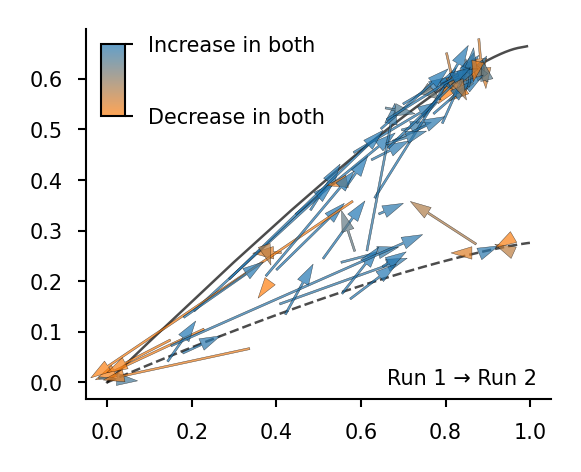

In [101]:
# I(X;R) and I(R;Y) on run 1 and run 2 for each individual, colored by direction of change
# EXCLUDE subjects with Ixr < 0.05 in both runs

include_subjects = alldata_beads.groupby('subject_index')['Ixr'].max() >= 0.05
subjects_to_include = include_subjects[include_subjects].index.tolist()

fig, ax = plt.subplots(figsize=(2, 1.6), dpi=300)

full_bound, = ax.plot(emp_bound_opt_beads['I_XR'],emp_bound_opt_beads['I_RY'], 'k', linewidth=0.6, label='Full IB bound',alpha=0.7)
heur_bound, = ax.plot(emp_bound_heur_beads['I_XR'], emp_bound_heur_beads['I_RY'], '--k', linewidth=0.6, label='Heuristic IB bound',alpha=0.7)

for sjind in subjects_to_include:
    sjconds = alldata_beads['subject_index'] == sjind
    sjconds_run1 = sjconds & (alldata_beads['run'] == 1)
    sjconds_run2 = sjconds & (alldata_beads['run'] == 2)
    sjcolor = generate_color(alldata_beads.loc[sjconds_run2,'Ixr'].values[0] - alldata_beads.loc[sjconds_run1,'Ixr'].values[0], alldata_beads.loc[sjconds_run2,'Iry'].values[0] - alldata_beads.loc[sjconds_run1,'Iry'].values[0], norm, diverging_cmap)
    ax.annotate('',xy=(alldata_beads.loc[sjconds_run2,'Ixr'].iat[0], alldata_beads.loc[sjconds_run2,'Iry'].iat[0]), xytext=(alldata_beads.loc[sjconds_run1,'Ixr'].iat[0], alldata_beads.loc[sjconds_run1,'Iry'].iat[0]),
                arrowprops=dict(facecolor=sjcolor, edgecolor='black', alpha=0.7, linewidth=0.1, width=0.5, headwidth=3, headlength=5))
    
ax.annotate(
    "Run 1 → Run 2",
    xy=(0.97, 0.03),  
    fontsize = 5,
    xycoords="axes fraction",
    ha="right",  
    va="bottom")
format_axis(ax)

colorbar_axis = plt.gcf().add_axes([0.15, 0.7, 0.04, 0.15])
sm = matplotlib.cm.ScalarMappable(cmap=diverging_cmap, norm=Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, cax=colorbar_axis, orientation='vertical',alpha=0.7)
cbar.set_ticks([0, 1],labels=['Decrease in both', 'Increase in both'])
cbar.ax.tick_params(labelsize=5, width=0.5, length=2)
cbar.outline.set_linewidth(0.5)
savefig(fig, 'Figure7/figure7_beads_learning-arrows')

In [102]:
conds = (alldata_beads['subject_index'].isin(subjects_to_include))
conds1 = conds & (alldata_beads['run'] == 1)
conds2 = conds & (alldata_beads['run'] == 2)

# number of participants who increased I(R;Y)
((alldata_beads.loc[conds2,'Iry'].to_numpy() - alldata_beads.loc[conds1,'Iry'].to_numpy()) > 0).sum()

47

In [103]:
from scipy.stats import wilcoxon

conds = (alldata_beads['subject_index'].isin(subjects_to_include))
conds1 = conds & (alldata_beads['run'] == 1)
conds2 = conds & (alldata_beads['run'] == 2)

result = wilcoxon(alldata_beads.loc[conds1, 'Ixr'], alldata_beads.loc[conds2, 'Ixr'])
print(f"Wilcoxon signed-rank test for Ixr_diff: statistic={result.statistic}, p-value={result.pvalue}, n={sum(conds1)}")

result = wilcoxon(alldata_beads.loc[conds1, 'Iry'], alldata_beads.loc[conds2, 'Iry'])
print(f"Wilcoxon signed-rank test for Iry_diff: statistic={result.statistic}, p-value={result.pvalue}, n={sum(conds1)}")

exclude_subjects = alldata_beads.groupby('subject_index')['Ixr'].min() < 0.05
subjects_to_exclude = exclude_subjects[exclude_subjects].index.tolist()

conds_ = ~alldata_beads['subject_index'].isin(subjects_to_exclude)
conds1_ = conds_ & (alldata_beads['run'] == 1)
conds2_ = conds_ & (alldata_beads['run'] == 2)

result = wilcoxon(alldata_beads.loc[conds1_, 'info_efficiency'], alldata_beads.loc[conds2_, 'info_efficiency'])
print(f"Wilcoxon signed-rank test for info_efficiency_diff: statistic={result.statistic}, p-value={result.pvalue}, n={sum(conds1_)}")

Wilcoxon signed-rank test for Ixr_diff: statistic=526.0, p-value=7.704888865613083e-05, n=68
Wilcoxon signed-rank test for Iry_diff: statistic=455.0, p-value=1.9311526067786113e-05, n=68
Wilcoxon signed-rank test for info_efficiency_diff: statistic=658.0, p-value=0.016568921624121238, n=63


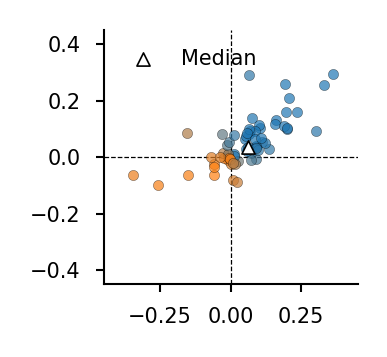

In [104]:
# Within-individual changes in Ixr and Iry between runs, colored by direction of change
# EXCLUDE subjects with Ixr < 0.05 in both runs

conds = alldata_beads['subject_index'].isin(subjects_to_include)
median_deltaIxr = np.median(alldata_beads.loc[conds & (alldata_beads['run'] == 2), 'Ixr'].to_numpy() - alldata_beads.loc[conds & (alldata_beads['run'] == 1), 'Ixr'].to_numpy())
median_deltaIry = np.median(alldata_beads.loc[conds & (alldata_beads['run'] == 2), 'Iry'].to_numpy() - alldata_beads.loc[conds & (alldata_beads['run'] == 1), 'Iry'].to_numpy())

fig, ax = plt.subplots(figsize=(1.1, 1.1), dpi=300)

ax.axhline(0, color='black', linewidth=0.3, linestyle='--', zorder=1)
ax.axvline(0, color='black', linewidth=0.3, linestyle='--', zorder=1)

for sjind in subjects_to_include:
    sjconds = alldata_beads['subject_index'] == sjind
    sjconds_run1 = sjconds & (alldata_beads['run'] == 1)
    sjconds_run2 = sjconds & (alldata_beads['run'] == 2)
    sjcolor = generate_color(alldata_beads.loc[sjconds_run2,'Ixr'].values[0] - alldata_beads.loc[sjconds_run1,'Ixr'].values[0], alldata_beads.loc[sjconds_run2,'Iry'].values[0] - alldata_beads.loc[sjconds_run1,'Iry'].values[0], norm, diverging_cmap)
    ax.scatter(alldata_beads.loc[sjconds_run2,'Ixr'].values[0] - alldata_beads.loc[sjconds_run1,'Ixr'].values[0], alldata_beads.loc[sjconds_run2,'Iry'].values[0] - alldata_beads.loc[sjconds_run1,'Iry'].values[0], color=sjcolor, s=6, edgecolors='black', alpha=0.7, linewidth=0.1, zorder=2)

ax.set_xlim(-0.45, 0.45)
ax.set_ylim(-0.45, 0.45)

ax.scatter(median_deltaIxr, median_deltaIry, color="white", edgecolors='black',
           marker="^", s=10, linewidth=0.4, zorder=5, clip_on=False, label="Median")

ax.legend(fontsize=5, frameon=False, loc='upper left')
format_axis(ax)
ax.set_aspect('equal', adjustable='box')
savefig(fig, 'Figure7/figure7_beads_learning_changes')

### Horse-prediction learning experiment

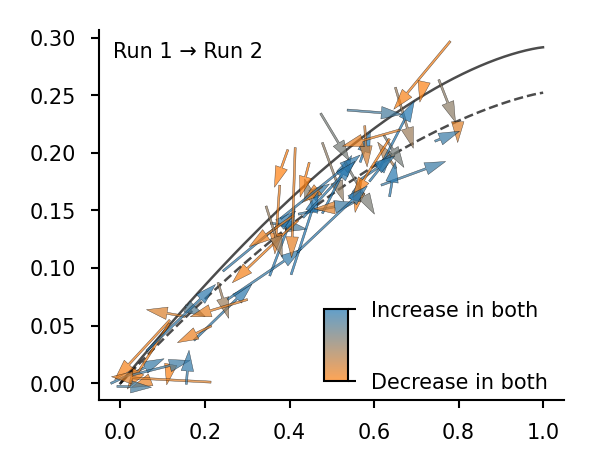

In [112]:
# I(X;R) and I(R;Y) on run 1 and run 2 for each individual, colored by direction of change
# EXCLUDE subjects with Ixr < 0.05 in both runs

exp = 'learning'
conditions = ['run_1', 'run_2']

alldata_ = alldata_dict[exp].copy()
conds = (alldata_['exclude_Ixr']==0)

fig, ax = plt.subplots(figsize=(2, 1.6), dpi=300)

full_bound, = ax.plot(bound_dict_horses['midWS']['full']['I_XR'], bound_dict_horses['midWS']['full']['I_RY'], 'k', linewidth=0.6, label='Full IB bound',alpha=0.7)
heur_bound, = ax.plot(bound_dict_horses['midWS']['equal-weights']['I_XR'], bound_dict_horses['midWS']['equal-weights']['I_RY'], '--k', linewidth=0.6, label='Heuristic IB bound',alpha=0.7)

for sjind in alldata_.loc[conds,'subject_index'].unique():
    sjconds = conds & (alldata_['subject_index'] == sjind)
    sjconds_cond1 = sjconds & (alldata_['condition'] == conditions[0])
    sjconds_cond2 = sjconds & (alldata_['condition'] == conditions[1])
    sjcolor = generate_color(alldata_.loc[sjconds_cond2,'Ixr'].values[0] - alldata_.loc[sjconds_cond1,'Ixr'].values[0], alldata_.loc[sjconds_cond2,'Iry'].values[0] - alldata_.loc[sjconds_cond1,'Iry'].values[0], norm, diverging_cmap)
    ax.annotate('',xy=(alldata_.loc[sjconds_cond2,'Ixr'].iat[0], alldata_.loc[sjconds_cond2,'Iry'].iat[0]), xytext=(alldata_.loc[sjconds_cond1,'Ixr'].iat[0], alldata_.loc[sjconds_cond1,'Iry'].iat[0]),
                arrowprops=dict(facecolor=sjcolor, edgecolor='black', alpha=0.7, linewidth=0.1, width=0.5, headwidth=3, headlength=5))
    
ax.annotate(
    "Run 1 → Run 2",
    xy=(0.03, 0.97),  
    fontsize = 5,
    xycoords="axes fraction",
    ha="left",  
    va="top")
format_axis(ax)

colorbar_axis = plt.gcf().add_axes([0.5, 0.15, 0.04, 0.15])
sm = matplotlib.cm.ScalarMappable(cmap=diverging_cmap, norm=Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, cax=colorbar_axis, orientation='vertical',alpha=0.7)
cbar.set_ticks([0, 1],labels=['Decrease in both', 'Increase in both'])
cbar.ax.tick_params(labelsize=5, width=0.5, length=2)
cbar.outline.set_linewidth(0.5)
savefig(fig, 'Figure7/figure7_horses_learning-arrows')

In [113]:
conds = (alldata_['exclude_Ixr']==0)
conds1 = conds & (alldata_['condition'] == conditions[0])
conds2 = conds & (alldata_['condition'] == conditions[1])

result = wilcoxon(alldata_.loc[conds1, 'Ixr'], alldata_.loc[conds2, 'Ixr'])
print(f"Wilcoxon signed-rank test for Ixr_diff: statistic={result.statistic}, p-value={result.pvalue}, n={sum(conds1)}")

result = wilcoxon(alldata_.loc[conds1, 'Iry'], alldata_.loc[conds2, 'Iry'])
print(f"Wilcoxon signed-rank test for Iry_diff: statistic={result.statistic}, p-value={result.pvalue}, n={sum(conds1)}")

exclude_subjects = alldata_.groupby('subject_index')['Ixr'].min() < 0.05
subjects_to_exclude = exclude_subjects[exclude_subjects].index.tolist()

conds_ = ~alldata_['subject_index'].isin(subjects_to_exclude)
conds1_ = conds_ & (alldata_['condition'] == conditions[0])
conds2_ = conds_ & (alldata_['condition'] == conditions[1])

result = wilcoxon(alldata_.loc[conds1_, 'info_efficiency'], alldata_.loc[conds2_, 'info_efficiency'])
print(f"Wilcoxon signed-rank test for info_efficiency_diff: statistic={result.statistic}, p-value={result.pvalue}, n={sum(conds1_)}")

Wilcoxon signed-rank test for Ixr_diff: statistic=663.0, p-value=0.06357852752398606, n=60
Wilcoxon signed-rank test for Iry_diff: statistic=840.0, p-value=0.5808659858919343, n=60
Wilcoxon signed-rank test for info_efficiency_diff: statistic=558.0, p-value=0.16322388329831405, n=53


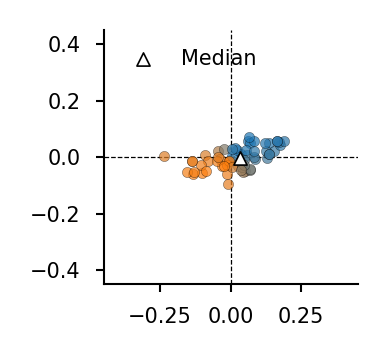

In [114]:
# Within-individual changes in Ixr and Iry between runs, colored by direction of change
# EXCLUDE subjects with Ixr < 0.05 in both runs

median_deltaIxr = np.median(alldata_.loc[conds & (alldata_['condition'] == conditions[1]), 'Ixr'].to_numpy() - alldata_.loc[conds & (alldata_['condition'] == conditions[0]), 'Ixr'].to_numpy())
median_deltaIry = np.median(alldata_.loc[conds & (alldata_['condition'] == conditions[1]), 'Iry'].to_numpy() - alldata_.loc[conds & (alldata_['condition'] == conditions[0]), 'Iry'].to_numpy())

fig, ax = plt.subplots(figsize=(1.1, 1.1), dpi=300)

ax.axhline(0, color='black', linewidth=0.3, linestyle='--', zorder=1)
ax.axvline(0, color='black', linewidth=0.3, linestyle='--', zorder=1)

for sjind in alldata_.loc[conds,'subject_index'].unique():
    sjconds = conds & (alldata_['subject_index'] == sjind)
    sjconds_cond1 = sjconds & (alldata_['condition'] == conditions[0])
    sjconds_cond2 = sjconds & (alldata_['condition'] == conditions[1])
    sjcolor = generate_color(alldata_.loc[sjconds_cond2,'Ixr'].values[0] - alldata_.loc[sjconds_cond1,'Ixr'].values[0], alldata_.loc[sjconds_cond2,'Iry'].values[0] - alldata_.loc[sjconds_cond1,'Iry'].values[0], norm, diverging_cmap)
    ax.scatter(alldata_.loc[sjconds_cond2,'Ixr'].values[0] - alldata_.loc[sjconds_cond1,'Ixr'].values[0], alldata_.loc[sjconds_cond2,'Iry'].values[0] - alldata_.loc[sjconds_cond1,'Iry'].values[0], color=sjcolor, s=6, edgecolors='black', alpha=0.7, linewidth=0.1, zorder=2)

ax.set_xlim(-0.45, 0.45)
ax.set_ylim(-0.45, 0.45)

ax.scatter(median_deltaIxr, median_deltaIry, color="white", edgecolors='black',
           marker="^", s=10, linewidth=0.4, zorder=5, clip_on=False, label="Median")

ax.legend(fontsize=5, frameon=False, loc='upper left')
format_axis(ax)
ax.set_aspect('equal', adjustable='box')
savefig(fig, 'Figure7/figure7_horses_learning_changes')

### Horse-prediction speed-accuracy experiment

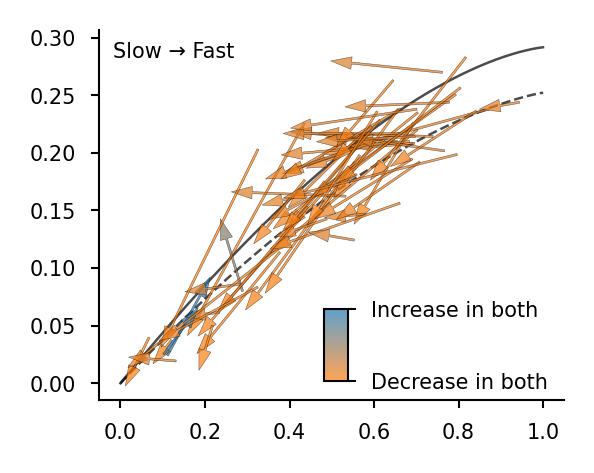

In [115]:
# I(X;R) and I(R;Y) on run 1 and run 2 for each individual, colored by direction of change
# EXCLUDE subjects with Ixr < 0.05 in both runs

exp = 'speed_accuracy'
conditions = ['slow', 'fast']

alldata_ = alldata_dict[exp].copy()
conds = (alldata_['exclude_Ixr']==0)

fig, ax = plt.subplots(figsize=(2, 1.6), dpi=300)

full_bound, = ax.plot(bound_dict_horses['midWS']['full']['I_XR'], bound_dict_horses['midWS']['full']['I_RY'], 'k', linewidth=0.6, label='Full IB bound',alpha=0.7)
heur_bound, = ax.plot(bound_dict_horses['midWS']['equal-weights']['I_XR'], bound_dict_horses['midWS']['equal-weights']['I_RY'], '--k', linewidth=0.6, label='Heuristic IB bound',alpha=0.7)

for sjind in alldata_.loc[conds,'subject_index'].unique():
    sjconds = conds & (alldata_['subject_index'] == sjind)
    sjconds_cond1 = sjconds & (alldata_['condition'] == conditions[0])
    sjconds_cond2 = sjconds & (alldata_['condition'] == conditions[1])
    sjcolor = generate_color(alldata_.loc[sjconds_cond2,'Ixr'].values[0] - alldata_.loc[sjconds_cond1,'Ixr'].values[0], alldata_.loc[sjconds_cond2,'Iry'].values[0] - alldata_.loc[sjconds_cond1,'Iry'].values[0], norm, diverging_cmap)
    ax.annotate('',xy=(alldata_.loc[sjconds_cond2,'Ixr'].iat[0], alldata_.loc[sjconds_cond2,'Iry'].iat[0]), xytext=(alldata_.loc[sjconds_cond1,'Ixr'].iat[0], alldata_.loc[sjconds_cond1,'Iry'].iat[0]),
                arrowprops=dict(facecolor=sjcolor, edgecolor='black', alpha=0.7, linewidth=0.1, width=0.5, headwidth=3, headlength=5))
    
ax.annotate(
    "Slow → Fast",
    xy=(0.03, 0.97),  
    fontsize = 5,
    xycoords="axes fraction",
    ha="left",  
    va="top")
format_axis(ax)

colorbar_axis = plt.gcf().add_axes([0.5, 0.15, 0.04, 0.15])
sm = matplotlib.cm.ScalarMappable(cmap=diverging_cmap, norm=Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, cax=colorbar_axis, orientation='vertical',alpha=0.7)
cbar.set_ticks([0, 1],labels=['Decrease in both', 'Increase in both'])
cbar.ax.tick_params(labelsize=5, width=0.5, length=2)
cbar.outline.set_linewidth(0.5)
savefig(fig, 'Figure7/figure7_speed-accuracy_arrows')

In [116]:
conds = (alldata_['exclude_Ixr']==0)
conds1 = conds & (alldata_['condition'] == conditions[0])
conds2 = conds & (alldata_['condition'] == conditions[1])

result = wilcoxon(alldata_.loc[conds1, 'Ixr'], alldata_.loc[conds2, 'Ixr'])
print(f"Wilcoxon signed-rank test for Ixr_diff: statistic={result.statistic}, p-value={result.pvalue}, n={sum(conds1)}")

result = wilcoxon(alldata_.loc[conds1, 'Iry'], alldata_.loc[conds2, 'Iry'])
print(f"Wilcoxon signed-rank test for Iry_diff: statistic={result.statistic}, p-value={result.pvalue}, n={sum(conds1)}")

exclude_subjects = alldata_.groupby('subject_index')['Ixr'].min() < 0.05
subjects_to_exclude = exclude_subjects[exclude_subjects].index.tolist()

conds_ = ~alldata_['subject_index'].isin(subjects_to_exclude)
conds1_ = conds_ & (alldata_['condition'] == conditions[0])
conds2_ = conds_ & (alldata_['condition'] == conditions[1])

result = wilcoxon(alldata_.loc[conds1_, 'info_efficiency'], alldata_.loc[conds2_, 'info_efficiency'])
print(f"Wilcoxon signed-rank test for info_efficiency_diff: statistic={result.statistic}, p-value={result.pvalue}, n={sum(conds1_)}")

Wilcoxon signed-rank test for Ixr_diff: statistic=19.0, p-value=4.22409488236999e-11, n=60
Wilcoxon signed-rank test for Iry_diff: statistic=194.0, p-value=1.1100756519178191e-07, n=60
Wilcoxon signed-rank test for info_efficiency_diff: statistic=628.0, p-value=0.1147670406074214, n=57


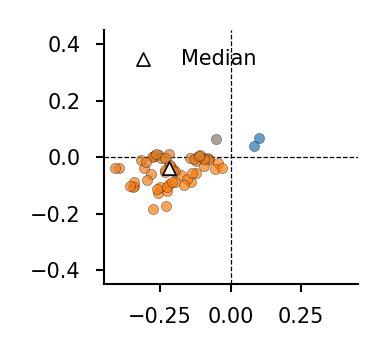

In [117]:
# Within-individual changes in Ixr and Iry between runs, colored by direction of change
# EXCLUDE subjects with Ixr < 0.05 in both runs

median_deltaIxr = np.median(alldata_.loc[conds & (alldata_['condition'] == conditions[1]), 'Ixr'].to_numpy() - alldata_.loc[conds & (alldata_['condition'] == conditions[0]), 'Ixr'].to_numpy())
median_deltaIry = np.median(alldata_.loc[conds & (alldata_['condition'] == conditions[1]), 'Iry'].to_numpy() - alldata_.loc[conds & (alldata_['condition'] == conditions[0]), 'Iry'].to_numpy())

fig, ax = plt.subplots(figsize=(1.1, 1.1), dpi=300)

ax.axhline(0, color='black', linewidth=0.3, linestyle='--', zorder=1)
ax.axvline(0, color='black', linewidth=0.3, linestyle='--', zorder=1)

for sjind in alldata_.loc[conds,'subject_index'].unique():
    sjconds = conds & (alldata_['subject_index'] == sjind)
    sjconds_cond1 = sjconds & (alldata_['condition'] == conditions[0])
    sjconds_cond2 = sjconds & (alldata_['condition'] == conditions[1])
    sjcolor = generate_color(alldata_.loc[sjconds_cond2,'Ixr'].values[0] - alldata_.loc[sjconds_cond1,'Ixr'].values[0], alldata_.loc[sjconds_cond2,'Iry'].values[0] - alldata_.loc[sjconds_cond1,'Iry'].values[0], norm, diverging_cmap)
    ax.scatter(alldata_.loc[sjconds_cond2,'Ixr'].values[0] - alldata_.loc[sjconds_cond1,'Ixr'].values[0], alldata_.loc[sjconds_cond2,'Iry'].values[0] - alldata_.loc[sjconds_cond1,'Iry'].values[0], color=sjcolor, s=6, edgecolors='black', alpha=0.7, linewidth=0.1, zorder=2)

ax.set_xlim(-0.45, 0.45)
ax.set_ylim(-0.45, 0.45)

ax.scatter(median_deltaIxr, median_deltaIry, color="white", edgecolors='black',
           marker="^", s=10, linewidth=0.4, zorder=5, clip_on=False, label="Median")

ax.legend(fontsize=5, frameon=False, loc='upper left')
format_axis(ax)
ax.set_aspect('equal', adjustable='box')
savefig(fig, 'Figure7/figure7_horses_speed-accuracy_changes')

### Horse-prediction reward experiment

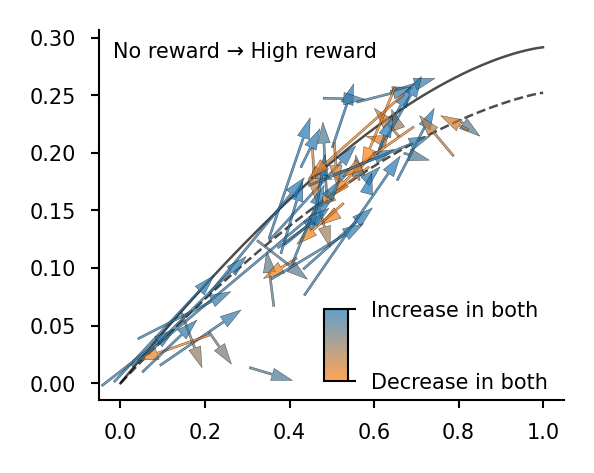

In [118]:
# I(X;R) and I(R;Y) on run 1 and run 2 for each individual, colored by direction of change
# EXCLUDE subjects with Ixr < 0.05 in both runs

exp = 'reward'
conditions = ['low_reward', 'high_reward']

alldata_ = alldata_dict[exp].copy()
conds = (alldata_['exclude_Ixr']==0)

fig, ax = plt.subplots(figsize=(2, 1.6), dpi=300)

full_bound, = ax.plot(bound_dict_horses['midWS']['full']['I_XR'], bound_dict_horses['midWS']['full']['I_RY'], 'k', linewidth=0.6, label='Full IB bound',alpha=0.7)
heur_bound, = ax.plot(bound_dict_horses['midWS']['equal-weights']['I_XR'], bound_dict_horses['midWS']['equal-weights']['I_RY'], '--k', linewidth=0.6, label='Heuristic IB bound',alpha=0.7)

for sjind in alldata_.loc[conds,'subject_index'].unique():
    sjconds = conds & (alldata_['subject_index'] == sjind)
    sjconds_cond1 = sjconds & (alldata_['condition'] == conditions[0])
    sjconds_cond2 = sjconds & (alldata_['condition'] == conditions[1])
    sjcolor = generate_color(alldata_.loc[sjconds_cond2,'Ixr'].values[0] - alldata_.loc[sjconds_cond1,'Ixr'].values[0], alldata_.loc[sjconds_cond2,'Iry'].values[0] - alldata_.loc[sjconds_cond1,'Iry'].values[0], norm, diverging_cmap)
    ax.annotate('',xy=(alldata_.loc[sjconds_cond2,'Ixr'].iat[0], alldata_.loc[sjconds_cond2,'Iry'].iat[0]), xytext=(alldata_.loc[sjconds_cond1,'Ixr'].iat[0], alldata_.loc[sjconds_cond1,'Iry'].iat[0]),
                arrowprops=dict(facecolor=sjcolor, edgecolor='black', alpha=0.7, linewidth=0.1, width=0.5, headwidth=3, headlength=5))
    
ax.annotate(
    "No reward → High reward",
    xy=(0.03, 0.97),  
    fontsize = 5,
    xycoords="axes fraction",
    ha="left",  
    va="top")
format_axis(ax)

colorbar_axis = plt.gcf().add_axes([0.5, 0.15, 0.04, 0.15])
sm = matplotlib.cm.ScalarMappable(cmap=diverging_cmap, norm=Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, cax=colorbar_axis, orientation='vertical',alpha=0.7)
cbar.set_ticks([0, 1],labels=['Decrease in both', 'Increase in both'])
cbar.ax.tick_params(labelsize=5, width=0.5, length=2)
cbar.outline.set_linewidth(0.5)
savefig(fig, 'Figure7/figure7_reward_arrows')

In [119]:
conds = (alldata_['exclude_Ixr']==0)
conds1 = conds & (alldata_['condition'] == conditions[0])
conds2 = conds & (alldata_['condition'] == conditions[1])

result = wilcoxon(alldata_.loc[conds1, 'Ixr'], alldata_.loc[conds2, 'Ixr'])
print(f"Wilcoxon signed-rank test for Ixr_diff: statistic={result.statistic}, p-value={result.pvalue}, n={sum(conds1)}")

result = wilcoxon(alldata_.loc[conds1, 'Iry'], alldata_.loc[conds2, 'Iry'])
print(f"Wilcoxon signed-rank test for Iry_diff: statistic={result.statistic}, p-value={result.pvalue}, n={sum(conds1)}")

exclude_subjects = alldata_.groupby('subject_index')['Ixr'].min() < 0.05
subjects_to_exclude = exclude_subjects[exclude_subjects].index.tolist()

conds_ = ~alldata_['subject_index'].isin(subjects_to_exclude)
conds1_ = conds_ & (alldata_['condition'] == conditions[0])
conds2_ = conds_ & (alldata_['condition'] == conditions[1])

result = wilcoxon(alldata_.loc[conds1_, 'info_efficiency'], alldata_.loc[conds2_, 'info_efficiency'])
print(f"Wilcoxon signed-rank test for info_efficiency_diff: statistic={result.statistic}, p-value={result.pvalue}, n={sum(conds1_)}")

Wilcoxon signed-rank test for Ixr_diff: statistic=448.0, p-value=0.0005863121323328691, n=60
Wilcoxon signed-rank test for Iry_diff: statistic=486.0, p-value=0.0015878599145679076, n=60
Wilcoxon signed-rank test for info_efficiency_diff: statistic=619.0, p-value=0.20581369835602792, n=55


In [120]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

alldata_test = alldata_.loc[conds].copy()

md = smf.mixedlm("Ixr ~ condition + block", alldata_test, groups=alldata_test['subject_index'])
mdf = md.fit()
print(mdf.summary())
print(mdf.pvalues)

PatsyError: Error evaluating factor: NameError: name 'block' is not defined
    Ixr ~ condition + block
                      ^^^^^

In [ ]:
alldata_test = alldata_.loc[conds].copy()

md = smf.mixedlm("Iry ~ condition + block", alldata_test, groups=alldata_test['subject_index'])
mdf = md.fit()
print(mdf.summary())
print(mdf.pvalues)

In [ ]:
alldata_test = alldata_.loc[conds_].copy()

md = smf.mixedlm("info_efficiency ~ condition + block", alldata_test, groups=alldata_test['subject_index'])
mdf = md.fit()
print(mdf.summary())
print(mdf.pvalues)

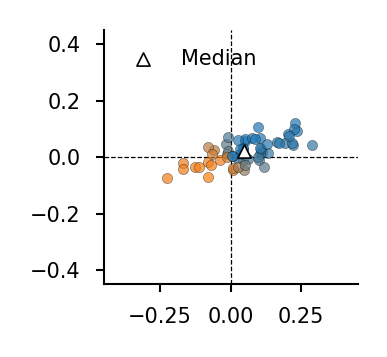

In [121]:
# Within-individual changes in Ixr and Iry between runs, colored by direction of change
# EXCLUDE subjects with Ixr < 0.05 in both runs

median_deltaIxr = np.median(alldata_.loc[conds & (alldata_['condition'] == conditions[1]), 'Ixr'].to_numpy() - alldata_.loc[conds & (alldata_['condition'] == conditions[0]), 'Ixr'].to_numpy())
median_deltaIry = np.median(alldata_.loc[conds & (alldata_['condition'] == conditions[1]), 'Iry'].to_numpy() - alldata_.loc[conds & (alldata_['condition'] == conditions[0]), 'Iry'].to_numpy())

fig, ax = plt.subplots(figsize=(1.1, 1.1), dpi=300)

ax.axhline(0, color='black', linewidth=0.3, linestyle='--', zorder=1)
ax.axvline(0, color='black', linewidth=0.3, linestyle='--', zorder=1)

for sjind in alldata_.loc[conds,'subject_index'].unique():
    sjconds = conds & (alldata_['subject_index'] == sjind)
    sjconds_cond1 = sjconds & (alldata_['condition'] == conditions[0])
    sjconds_cond2 = sjconds & (alldata_['condition'] == conditions[1])
    sjcolor = generate_color(alldata_.loc[sjconds_cond2,'Ixr'].values[0] - alldata_.loc[sjconds_cond1,'Ixr'].values[0], alldata_.loc[sjconds_cond2,'Iry'].values[0] - alldata_.loc[sjconds_cond1,'Iry'].values[0], norm, diverging_cmap)
    ax.scatter(alldata_.loc[sjconds_cond2,'Ixr'].values[0] - alldata_.loc[sjconds_cond1,'Ixr'].values[0], alldata_.loc[sjconds_cond2,'Iry'].values[0] - alldata_.loc[sjconds_cond1,'Iry'].values[0], color=sjcolor, s=6, edgecolors='black', alpha=0.7, linewidth=0.1, zorder=2)

ax.set_xlim(-0.45, 0.45)
ax.set_ylim(-0.45, 0.45)

ax.scatter(median_deltaIxr, median_deltaIry, color="white", edgecolors='black',
           marker="^", s=10, linewidth=0.4, zorder=5, clip_on=False, label="Median")

ax.legend(fontsize=5, frameon=False, loc='upper left')
format_axis(ax)
ax.set_aspect('equal', adjustable='box')
savefig(fig, 'Figure7/figure7_horses_reward_changes')